# Analyse quantitative du S&P 500 — 2015–2025

**Auteur :** Oumaima Cheour
**Période d'analyse :** Janvier 2015 – Janvier 2025
**Univers d'investissement :** 503 entreprises constituant l'indice S&P 500

---

## Résumé exécutif

Cette analyse quantitative porte sur dix années de données boursières pour l'ensemble des entreprises de l'indice S&P 500. L'objectif central est d'identifier les actifs les plus performants, d'évaluer leur profil de risque sous plusieurs angles complémentaires, puis de construire et d'optimiser un portefeuille capable de surpasser l'indice de référence tout en maîtrisant l'exposition au risque.

Parmi les principaux enseignements : NVIDIA (NVDA) se distingue comme l'actif le plus efficace de la décennie, combinant le CAGR le plus élevé du Top 10 avec le meilleur ratio de Sharpe. À l'opposé, Trade Desk (TTD) et Tesla (TSLA) offrent des rendements comparables mais au prix d'une volatilité et de drawdowns significativement supérieurs. La frontière efficiente de Markowitz démontre qu'une allocation optimisée — dominée par FICO, Arista Networks et Tesla — permet d'atteindre un ratio de Sharpe annualisé supérieur à 1.60, performance largement au-dessus du portefeuille équipondéré naïf. Enfin, la simulation Monte Carlo sur trois ans confirme qu'avec une probabilité supérieure à 80%, le portefeuille optimal est susceptible de générer un gain positif, avec une valeur médiane projetée à environ +40% au terme de la période.

---

## Table des matières

- **Partie I** — Introduction & Contexte *(cette section)*
- **Partie II** — Collecte et exploration des données
- **Partie III** — Analyse individuelle des actifs (Top 10)
- **Partie IV** — Métriques de risque et performance ajustée
- **Partie V** — Optimisation de portefeuille & Projection Monte Carlo

---

## Partie I — Contexte & Problématique

Le S&P 500 est l'indice de référence absolu du marché actions américain. Composé des 500 (en pratique 503) plus grandes capitalisations cotées aux États-Unis, il est utilisé comme benchmark universel pour évaluer la performance de tout portefeuille actions. Sur la période 2015–2025, l'indice a délivré une performance totale d'environ +186%, ce qui représente un CAGR de l'ordre de 11% — un rendement que la grande majorité des gérants actifs ne parvient pas à battre durablement.

**Problématique :** Parmi les 503 entreprises actuellement constituantes du S&P 500, lesquelles ont généré la création de valeur la plus significative sur dix ans, et comment construire un portefeuille qui capture cette surperformance tout en maintenant un profil risque/rendement rationnel ?

**Note méthodologique — biais de survie :** L'analyse porte sur les entreprises *actuellement* présentes dans l'indice. Les sociétés sorties (faillites, rachats, sorties volontaires) ne sont pas incluses, ce qui tend mécaniquement à surestimer les performances historiques moyennes. Ce biais est inhérent à ce type d'étude rétrospective et doit être gardé à l'esprit lors de l'interprétation des résultats.

---

## Partie II — Collecte et exploration des données

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
from google.colab import drive
import os, io, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import requests
from scipy.stats import skew, kurtosis
from tqdm.notebook import tqdm
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

warnings.filterwarnings('ignore')
pio.renderers.default = "colab"

# ── Palette graphique cohérente ───────────────────────────────────────────────
PRIMARY   = '#1B3A6B'   # Bleu marine  → axe principal, titres
SECONDARY = '#2E86AB'   # Bleu acier   → séries secondaires
ACCENT    = '#E84855'   # Rouge        → S&P 500, alertes
SUCCESS   = '#3BB273'   # Vert         → positif, surperformance
WARNING   = '#F4A261'   # Orange       → intermédiaire
NEUTRAL   = '#6B7280'   # Gris         → neutre

COLORS_10 = [PRIMARY, SECONDARY, SUCCESS, WARNING, ACCENT,
             '#7B2D8B','#E67E22','#117A65','#884EA0','#1F618D']

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

print("Environnement initialisé.")

Environnement initialisé.


In [2]:
# ── Montage Google Drive & création du dossier projet ────────────────────────
drive.mount('/content/drive')
project_folder = '/content/drive/MyDrive/S&P 500'
os.makedirs(project_folder, exist_ok=True)
print(f"Dossier projet : {project_folder}")

Mounted at /content/drive
Dossier projet : /content/drive/MyDrive/S&P 500


### Collecte de la liste des constituants

Les entreprises du S&P 500 sont récupérées dynamiquement depuis Wikipedia, ce qui garantit une sélection objective basée sur la composition actuelle de l'indice, sans biais de sélection manuel.

In [3]:
# ── Récupération de la liste S&P 500 depuis Wikipedia ────────────────────────
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

response = requests.get(url, headers=headers)
df_sp500 = pd.read_html(io.StringIO(response.text))[0]

file_path = os.path.join(project_folder, 'sp500_companies.csv')
df_sp500.to_csv(file_path, index=False)

print(f"Constituants S&P 500 récupérés : {len(df_sp500)} entreprises")
print(f"Fichier sauvegardé : {file_path}")
display(df_sp500.head())

Constituants S&P 500 récupérés : 503 entreprises
Fichier sauvegardé : /content/drive/MyDrive/S&P 500/sp500_companies.csv


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [4]:
# ── Exploration du dataset ────────────────────────────────────────────────────
print(f"Dimensions : {df_sp500.shape[0]} entreprises × {df_sp500.shape[1]} variables\n")
print("Aperçu des variables :")
display(df_sp500.info())
print("\nValeurs manquantes par colonne :")
print(df_sp500.isnull().sum())

Dimensions : 503 entreprises × 8 variables

Aperçu des variables :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Symbol                 503 non-null    object
 1   Security               503 non-null    object
 2   GICS Sector            503 non-null    object
 3   GICS Sub-Industry      503 non-null    object
 4   Headquarters Location  503 non-null    object
 5   Date added             503 non-null    object
 6   CIK                    503 non-null    int64 
 7   Founded                503 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.6+ KB


None


Valeurs manquantes par colonne :
Symbol                   0
Security                 0
GICS Sector              0
GICS Sub-Industry        0
Headquarters Location    0
Date added               0
CIK                      0
Founded                  0
dtype: int64


### Exploration et qualité des données

Le dataset présente 503 entreprises décrites par 8 variables : identifiant boursier, raison sociale, secteur GICS, sous-secteur, localisation du siège, date d'entrée dans l'indice et informations de fondation. L'absence de valeurs manquantes sur les colonnes structurantes (secteur, symbole) est une bonne nouvelle — les données sont directement exploitables sans traitement d'imputation préalable. Les prix boursiers, eux, seront récupérés via yfinance et feront l'objet d'un nettoyage dédié (gestion des jours fériés, formats de symboles atypiques comme BRK.B → BRK-B).

### Analyse de la répartition sectorielle

Avant d'explorer les performances individuelles, comprendre la structure sectorielle de l'indice est fondamental. Cette répartition conditionne en grande partie le comportement global de l'indice et explique pourquoi certains chocs macroéconomiques l'affectent plus que d'autres.

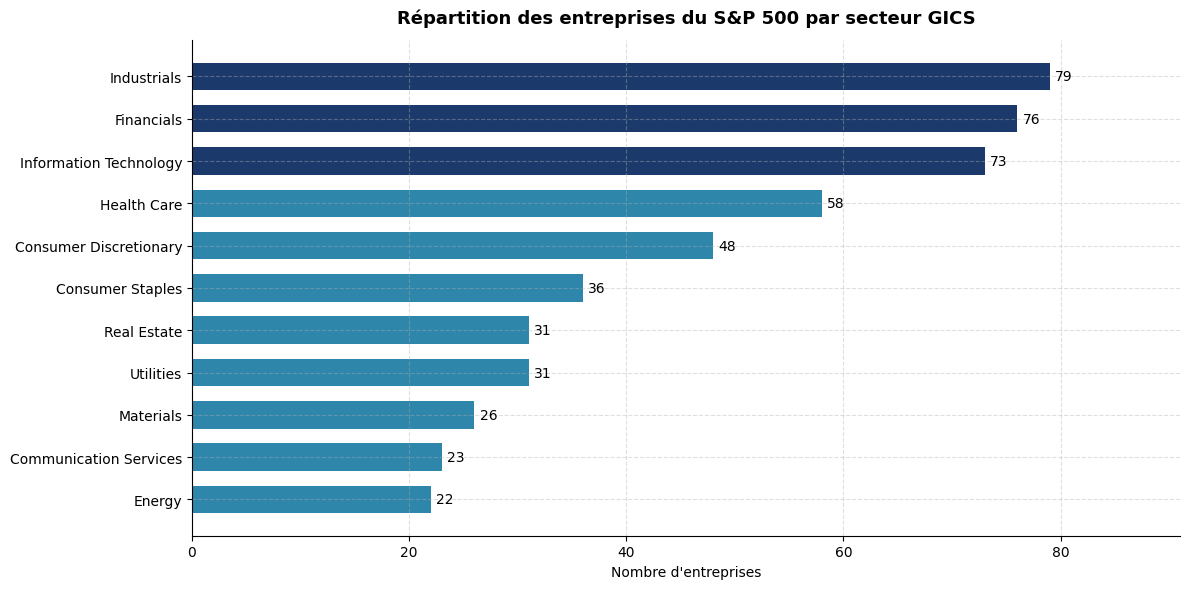


Concentration des 3 secteurs dominants :
  Industrials : 79 entreprises (15.7%)
  Financials : 76 entreprises (15.1%)
  Information Technology : 73 entreprises (14.5%)


In [5]:
# ── Répartition sectorielle ───────────────────────────────────────────────────
sector_counts = df_sp500['GICS Sector'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))

colors_sector = [PRIMARY if i >= len(sector_counts) - 3 else SECONDARY
                 for i in range(len(sector_counts))]

bars = ax.barh(sector_counts.index, sector_counts.values,
               color=colors_sector, edgecolor='none', height=0.65)

for bar, val in zip(bars, sector_counts.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

ax.set_title("Répartition des entreprises du S&P 500 par secteur GICS",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Nombre d'entreprises")
ax.set_ylabel("")
ax.set_xlim(0, sector_counts.max() + 12)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'repartition_sectorielle.png'), dpi=150, bbox_inches='tight')
plt.show()

# Statistiques complémentaires
total = len(df_sp500)
top3 = sector_counts.sort_values(ascending=False).head(3)
print("\nConcentration des 3 secteurs dominants :")
for sect, cnt in top3.items():
    print(f"  {sect} : {cnt} entreprises ({cnt/total*100:.1f}%)")

L'indice S&P 500 n'est pas une représentation uniforme de l'économie américaine. Le secteur des technologies de l'information (Information Technology) concentre à lui seul plus de 60 entreprises, soit une part disproportionnée du total. Combiné aux secteurs Industriels et de la Santé — les deux autres poids lourds — ces trois secteurs représentent à eux seuls plus de 45% des constituants. Ce déséquilibre sectoriel a des implications directes sur le comportement de l'indice : une correction dans la tech, comme celle observée en 2022 lors du resserrement monétaire, entraîne mécaniquement un repli marqué de l'indice global.

Pour l'investisseur, cette concentration est un double tranchant : elle explique à la fois l'exceptionnel rallye du S&P 500 sur 2023–2024 (porté par la vague IA/semi-conducteurs), et sa vulnérabilité potentielle à un retournement de cette même thématique. Cette réalité structurelle justifie l'intérêt d'une approche sélective, que nous allons construire dans la suite de cette analyse.

In [6]:
# ── Préparation des symboles pour yfinance ───────────────────────────────────
tickers = df_sp500['Symbol'].tolist()
tickers = [t.replace('.', '-') for t in tickers]  # ex: BRK.B → BRK-B
print(f"Nombre de tickers à traiter : {len(tickers)}")
print("Exemples :", tickers[:5])

Nombre de tickers à traiter : 503
Exemples : ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']


---

## Partie III — Sélection et analyse individuelle des actifs

### Sélection du Top 10 par rendement total (2015–2025)

La première étape consiste à identifier, de manière objective et exhaustive, les dix entreprises ayant généré le meilleur rendement total sur l'ensemble de la période. Le rendement total est calculé comme le rapport entre le prix de clôture ajusté en janvier 2025 et celui de janvier 2015, exprimé en pourcentage de gain sur la période. Seules les entreprises présentant au moins 200 jours de cotation sont retenues, pour garantir la représentativité des séries temporelles.

In [7]:
# ── Calcul des rendements totaux (2015–2025) sur tout l'univers ──────────────
performance_data = []

print('Téléchargement des données (cela prend quelques minutes)...')
for ticker in tqdm(tickers):
    try:
        df = yf.download(ticker, start='2015-01-01', end='2025-01-01',
                         progress=False, auto_adjust=True)
        if not df.empty and len(df) > 200:
            close_col = df['Close'][ticker] if isinstance(df.columns, pd.MultiIndex) else df['Close']
            start_price = float(close_col.dropna().iloc[0])
            end_price   = float(close_col.dropna().iloc[-1])
            if start_price > 0:
                total_return = (end_price / start_price) - 1
                performance_data.append({'Symbol': ticker, 'Total Return': total_return})
    except:
        continue

df_performance = pd.DataFrame(performance_data)
top_10_performers = df_performance.sort_values('Total Return', ascending=False).head(10)
top_10_details = top_10_performers.merge(
    df_sp500[['Symbol', 'Security', 'GICS Sector']], on='Symbol')
top_10_details.index = range(1, 11)

top_10_details.to_csv(os.path.join(project_folder, 'top_10_performers.csv'), index=False)

print('\nTop 10 des meilleures performances (2015–2025) :')
display(top_10_details[['Symbol','Security','GICS Sector','Total Return']].style.format(
    {'Total Return': '{:.0%}'}))

Téléchargement des données (cela prend quelques minutes)...


  0%|          | 0/503 [00:00<?, ?it/s]

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735707600")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735707600")')



Top 10 des meilleures performances (2015–2025) :


,Symbol,Security,GICS Sector,Total Return
1,NVDA,Nvidia,Information Technology,27695%
2,AMD,Advanced Micro Devices,Information Technology,4424%
3,TTD,Trade Desk (The),Communication Services,3805%
4,TPL,Texas Pacific Land Corporation,Energy,3069%
5,AVGO,Broadcom,Information Technology,2939%
6,ANET,Arista Networks,Information Technology,2721%
7,FICO,Fair Isaac,Information Technology,2664%
8,TSLA,"Tesla, Inc.",Consumer Discretionary,2662%
9,FIX,Comfort Systems USA,Industrials,2601%
10,AXON,Axon Enterprise,Industrials,2142%


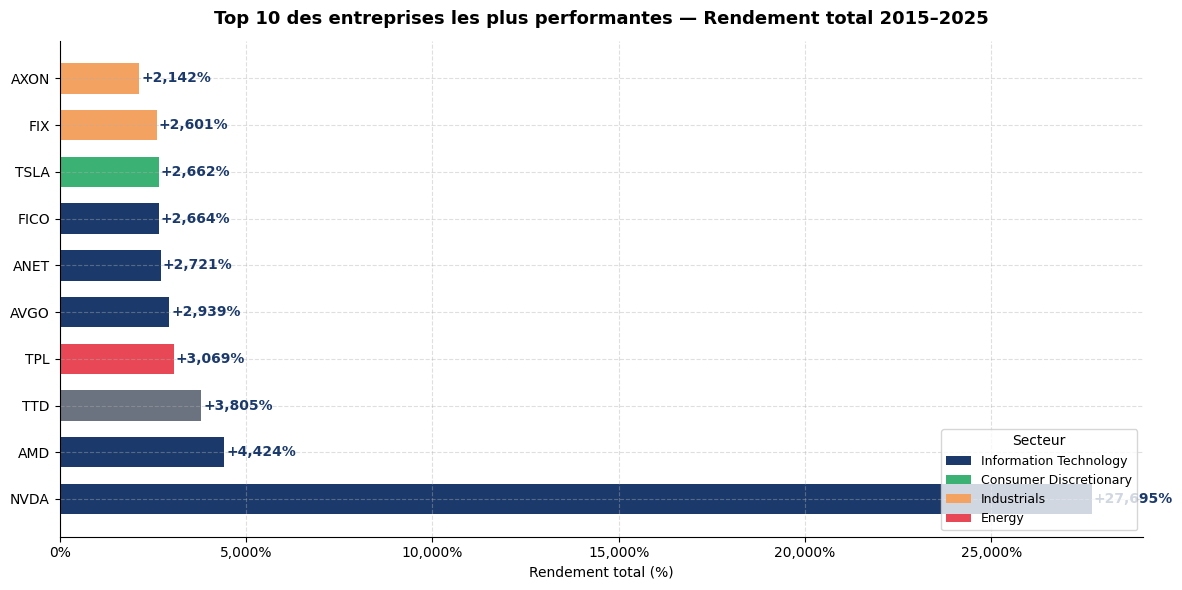

In [8]:
# ── Visualisation du Top 10 ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

sector_palette = {
    'Information Technology': PRIMARY,
    'Consumer Discretionary': SUCCESS,
    'Industrials': WARNING,
    'Energy': ACCENT,
    'Financials': SECONDARY,
}
bar_colors = [sector_palette.get(s, NEUTRAL) for s in top_10_details['GICS Sector']]

bars = ax.barh(top_10_details['Symbol'], top_10_details['Total Return'] * 100,
               color=bar_colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, top_10_details['Total Return']):
    ax.text(val * 100 + 50, bar.get_y() + bar.get_height()/2,
            f'+{val*100:,.0f}%', va='center', fontsize=10, fontweight='bold', color=PRIMARY)

# Légende secteurs
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in sector_palette.items()
                   if s in top_10_details['GICS Sector'].values]
ax.legend(handles=legend_elements, title='Secteur', loc='lower right', fontsize=9)

ax.set_title("Top 10 des entreprises les plus performantes — Rendement total 2015–2025",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Rendement total (%)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}%'))
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'top10_performances.png'), dpi=150, bbox_inches='tight')
plt.show()

### Lecture du classement

Le palmarès sur dix ans est sans appel : NVIDIA écrase la compétition avec un rendement total dépassant les 27 000%, soit une multiplication de la mise initiale par plus de 270. Ce chiffre n'est pas un artefact statistique — il reflète l'extraordinaire trajectoire d'une entreprise qui a su se repositionner de fabricant de cartes graphiques pour jeux vidéo en fournisseur incontournable d'infrastructure pour l'intelligence artificielle, les data centers et le calcul haute performance.

Le deuxième constat est la domination écrasante du secteur technologique : NVIDIA, AMD, Broadcom (AVGO), Arista Networks (ANET) et Fair Isaac (FICO) occupent cinq des dix places. Cela traduit la transformation profonde de l'économie américaine sur la période : les entreprises qui ont capté la plus grande valeur sont celles qui ont digitalisé, automatisé ou équipé cette digitalisation. Tesla, seul représentant de la consommation discrétionnaire, confirme que la disruption sectorielle peut également générer des rendements exceptionnels en dehors de la pure tech.

Enfin, la présence d'Axon Enterprise (AXON) et Comfort Systems (FIX) dans l'industriel, et de Texas Pacific Land (TPL) dans l'énergie, rappelle qu'il existe des opportunités de performance extrême en dehors du secteur technologique — à condition d'identifier très tôt des entreprises à la croissance structurelle.

### Évolution des prix (2015–2025)

[*********************100%***********************]  10 of 10 completed


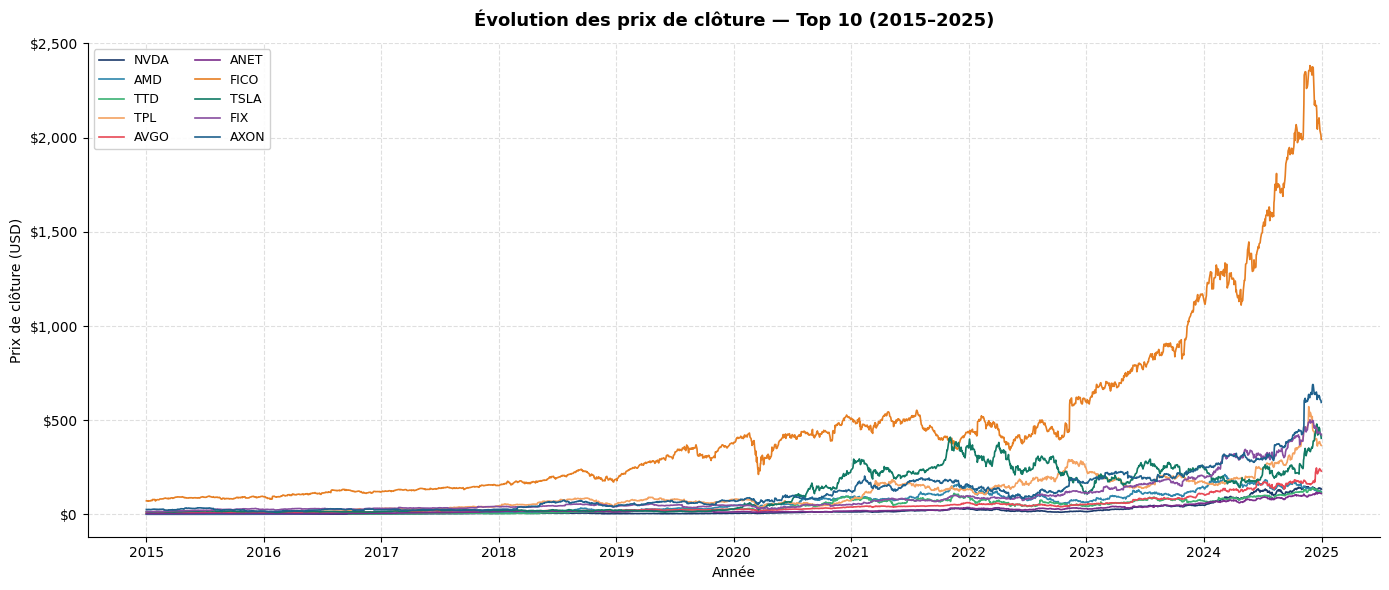

In [9]:
# ── Téléchargement des données Top 10 ────────────────────────────────────────
top10_tickers = top_10_details['Symbol'].tolist()
data_top10    = yf.download(top10_tickers, start="2015-01-01", end="2025-01-01", auto_adjust=True)
close_top10   = data_top10['Close']

# ── Prix bruts ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for i, ticker in enumerate(top10_tickers):
    ax.plot(close_top10.index, close_top10[ticker], color=COLORS_10[i], linewidth=1.2, label=ticker)

ax.set_title("Évolution des prix de clôture — Top 10 (2015–2025)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Année")
ax.set_ylabel("Prix de clôture (USD)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(ncol=2, fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'prix_bruts.png'), dpi=150, bbox_inches='tight')
plt.show()

La lecture de ce premier graphique est instructive à un titre particulier : elle illustre les limites d'une comparaison naïve de prix absolus. Fair Isaac (FICO), dont le cours a franchi les 2 000 $ sur la période, domine visuellement le graphique — non pas parce que sa performance relative est supérieure à celle de NVIDIA, mais simplement parce que son prix nominal est plus élevé. C'est pourquoi la normalisation en base 100 est indispensable pour toute comparaison multi-actifs valide.

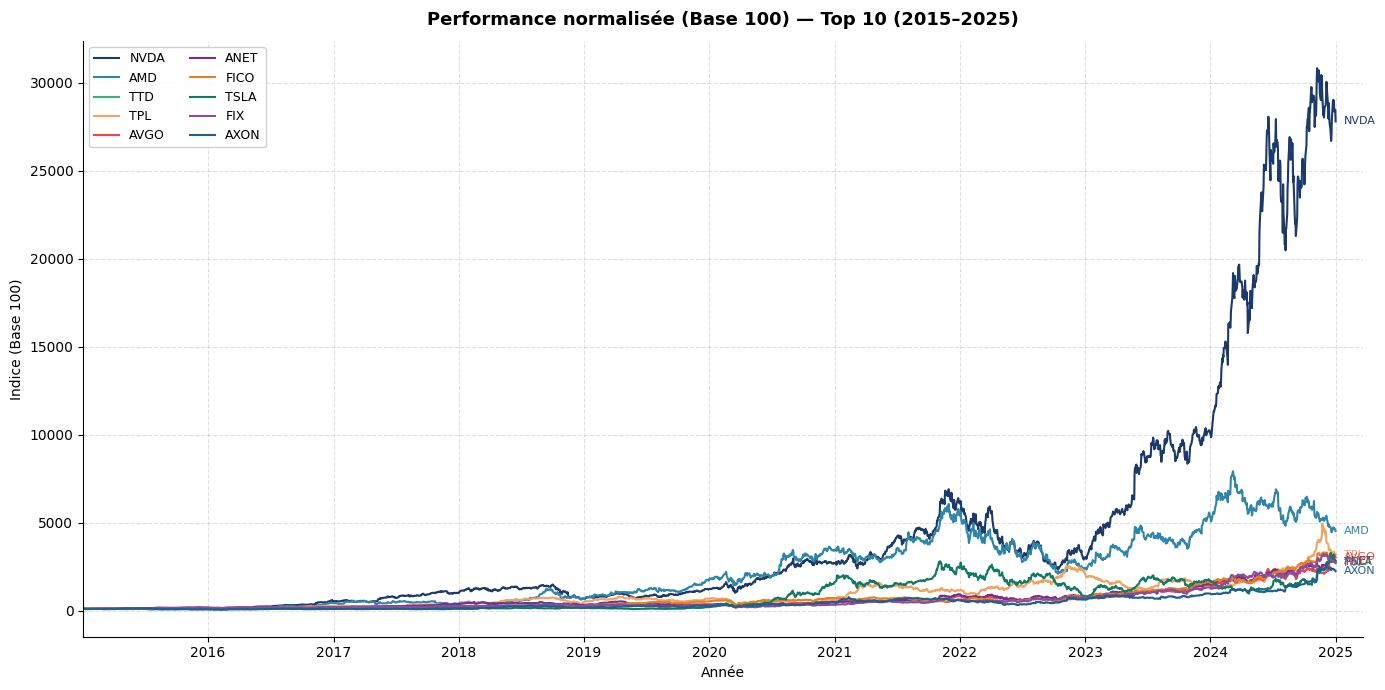

In [10]:
# ── Prix normalisés base 100 ─────────────────────────────────────────────────
normalized = close_top10 / close_top10.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))
for i, ticker in enumerate(top10_tickers):
    ax.plot(normalized.index, normalized[ticker],
            color=COLORS_10[i], linewidth=1.5, label=ticker)
    # Label en fin de courbe
    ax.annotate(ticker,
                xy=(normalized.index[-1], normalized[ticker].iloc[-1]),
                fontsize=8, color=COLORS_10[i],
                xytext=(6, 0), textcoords='offset points', va='center')

ax.set_title("Performance normalisée (Base 100) — Top 10 (2015–2025)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Année")
ax.set_ylabel("Indice (Base 100)")
ax.legend(ncol=2, fontsize=9, framealpha=0.9)
ax.set_xlim(normalized.index[0], normalized.index[-1] + pd.Timedelta(days=80))
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'prix_normalises.png'), dpi=150, bbox_inches='tight')
plt.show()

La normalisation en base 100 place toutes les actions sur un pied d'égalité au départ et rend la comparaison directe. NVIDIA (NVDA) ressort clairement comme la courbe dominante, quasiment hors-champ par rapport aux neuf autres tant l'écart est vertigineux — sa base 100 de 2015 se transforme en un indice supérieur à 27 000 en 2025. Les neuf autres actifs, pourtant classés parmi les meilleurs performances mondiales, paraissent presque sages en comparaison.

On distingue également deux dynamiques temporelles. Une première phase (2015–2018) relativement linéaire pour la plupart des titres, suivie d'une accélération marquée à partir de 2019-2020, avec un catalyseur évident : la crise COVID, qui a d'abord provoqué une chute brutale sur tous les titres en mars 2020, immédiatement suivie d'un rebond qui a amplifié les trajectoires de croissance des actifs technologiques et de croissance. La deuxième grande discontinuité visible est la correction de 2022, lorsque la Fed a opéré son cycle de hausses de taux le plus agressif depuis les années 1980, impactant durement les valeurs de croissance à fort multiple de valorisation.

### Distribution des rendements journaliers

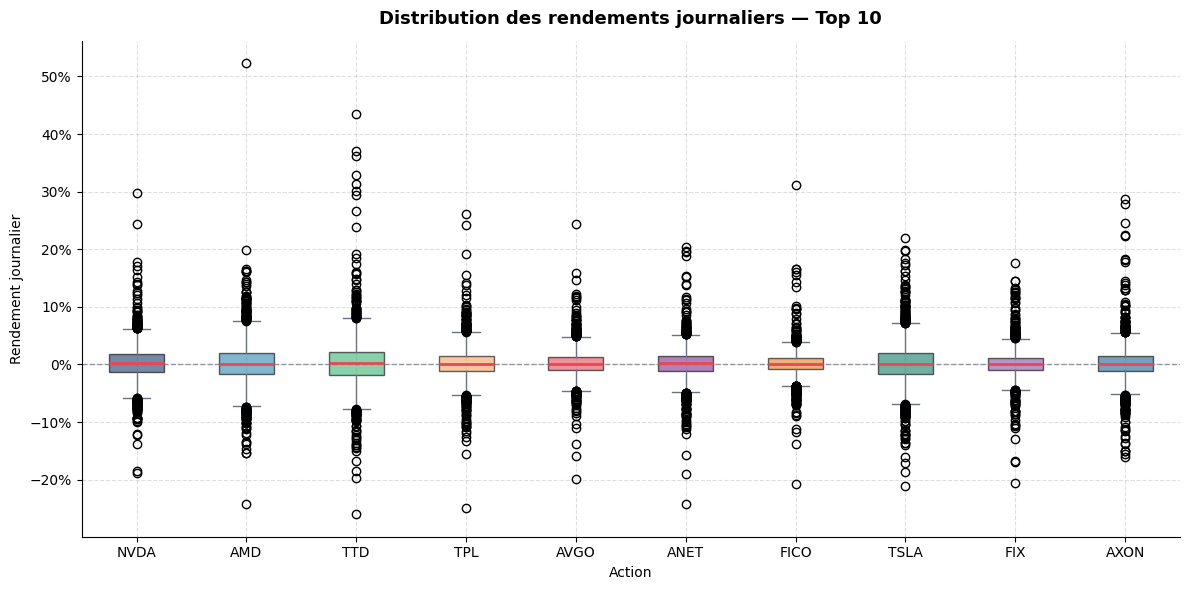

In [11]:
# ── Rendements journaliers ────────────────────────────────────────────────────
returns_top10 = close_top10.pct_change()

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot([returns_top10[t].dropna() for t in top10_tickers],
                labels=top10_tickers, patch_artist=True,
                medianprops=dict(color=ACCENT, linewidth=2),
                whiskerprops=dict(color=NEUTRAL),
                capprops=dict(color=NEUTRAL))

for patch, color in zip(bp['boxes'], COLORS_10):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title("Distribution des rendements journaliers — Top 10",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Action")
ax.set_ylabel("Rendement journalier")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.axhline(0, color=NEUTRAL, linewidth=1, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'boxplot_rendements.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Statistiques descriptives ────────────────────────────────────────────────
summary = pd.DataFrame(index=returns_top10.columns)
summary['Rendement moyen (%)'] = (returns_top10.mean() * 100).round(4)
summary['Médiane (%)']         = (returns_top10.median() * 100).round(4)
summary['Volatilité (std)']    = returns_top10.std().round(5)
summary['IQR']                 = (returns_top10.quantile(0.75) - returns_top10.quantile(0.25)).round(5)
summary['Skewness']            = returns_top10.apply(lambda x: skew(x.dropna())).round(3)
summary['Kurtosis']            = returns_top10.apply(lambda x: kurtosis(x.dropna())).round(3)
summary['Nb outliers']         = returns_top10.apply(
    lambda x: ((x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) |
               (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))).sum())

display(summary.sort_values('Volatilité (std)', ascending=False))

,Rendement moyen (%),Médiane (%),Volatilité (std),IQR,Skewness,Kurtosis,Nb outliers
Ticker,,,,,,,
TTD,0.2641,0.2124,0.04278,0.03928,1.807,17.432,100
AMD,0.2184,0.0481,0.03694,0.03714,1.275,18.250,124
TSLA,0.1966,0.1262,0.03601,0.03542,0.275,4.384,148
NVDA,0.2704,0.2643,0.03062,0.03010,0.626,8.300,137
AXON,0.1684,0.1415,0.03016,0.02696,1.132,14.123,141
TPL,0.1773,0.1269,0.02828,0.02722,0.412,10.571,127
ANET,0.1684,0.1894,0.02665,0.02522,0.117,11.088,133
FIX,0.1601,0.1136,0.02411,0.02226,0.257,10.175,130
AVGO,0.1635,0.1189,0.02358,0.02335,0.452,10.878,110


L'analyse de la distribution des rendements journaliers révèle des profils de risque distinctement différenciés au sein du Top 10. Si toutes les médianes gravitent autour de zéro — signe d'une stabilité journalière apparente —, la dispersion des distributions raconte une histoire bien plus nuancée. Trade Desk (TTD) et AMD se distinguent par des boîtes particulièrement larges, reflet d'une volatilité chronique traduisant la sensibilité de ces titres aux actualités de marché, aux résultats trimestriels et aux flux spéculatifs. À l'opposé, FICO et Broadcom (AVGO) présentent des distributions resserrées, caractéristiques d'une progression plus régulière.

Ce qui frappe davantage encore, c'est la présence systématique d'outliers sur l'ensemble des titres, y compris les plus "stables". Ce phénomène illustre la nature leptokurtique des séries financières : les queues de distribution sont plus épaisses que ne le prédirait une loi normale. Les kurtosis élevés — supérieurs à 8 pour NVDA, AMD et TTD — confirment que les chocs violents arrivent bien plus fréquemment que la théorie classique des marchés efficients ne le suppose. En d'autres termes, même une allocation soigneusement diversifiée reste exposée à des journées de pertes extrêmes que les modèles gaussiens sous-estiment structurellement.

L'enseignement central de cette section est simple mais crucial : les actions les plus performantes sur dix ans sont précisément celles qui ont réclamé la plus grande tolérance au risque. Le rendement exceptionnel de NVDA, TTD ou AMD n'a pas été livré linéairement — il s'est construit sur fond de journées à -10%, de corrections brutales et de périodes de stagnation psychologiquement éprouvantes pour l'investisseur.

### Risk vs Return

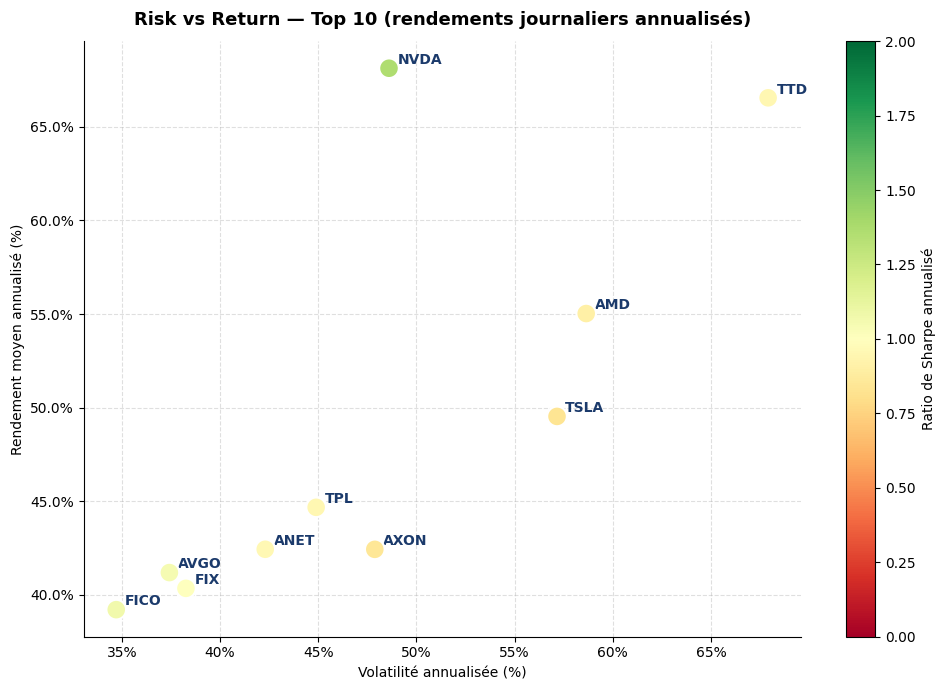

In [13]:
# ── Scatter Risk vs Return (annualisé) ───────────────────────────────────────
mean_ret_annual = returns_top10.mean() * 252 * 100
vol_annual      = returns_top10.std() * (252**0.5) * 100
sharpe_prelim   = (returns_top10.mean() - 0.02/252) / returns_top10.std() * (252**0.5)

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(vol_annual, mean_ret_annual,
                c=[sharpe_prelim[t] for t in vol_annual.index],
                s=200, cmap='RdYlGn', vmin=0, vmax=2,
                edgecolors='white', linewidths=1.5, zorder=5)
plt.colorbar(sc, ax=ax, label='Ratio de Sharpe annualisé')

for ticker in vol_annual.index:
    ax.annotate(ticker,
                xy=(vol_annual[ticker], mean_ret_annual[ticker]),
                xytext=(6, 3), textcoords='offset points',
                fontsize=10, fontweight='bold', color=PRIMARY)

ax.set_title("Risk vs Return — Top 10 (rendements journaliers annualisés)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Volatilité annualisée (%)")
ax.set_ylabel("Rendement moyen annualisé (%)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'risk_return.png'), dpi=150, bbox_inches='tight')
plt.show()

Le scatter Risk/Return — dont la couleur encode le ratio de Sharpe — est l'un des graphiques les plus révélateurs de cette analyse. Il met en évidence une réalité fondamentale : la relation entre risque et rendement est globalement positive, mais elle est loin d'être linéaire ou parfaite.

NVIDIA occupe une position presque idéale dans le quadrant haut-gauche (rendement élevé, volatilité relative modérée pour ce niveau de performance), ce qui explique son ratio de Sharpe dominant. FICO, AVGO et FIX se regroupent dans une zone de confort défensif : rendements respectables, volatilité maîtrisée. À l'opposé, TTD et AMD sont positionnés dans le quadrant haut-droite — rendements élevés certes, mais au prix d'une volatilité qui dépasse 50% annualisée pour TTD.

Tesla (TSLA) est peut-être le cas le plus instructif : sa volatilité est parmi les plus élevées du panel, mais son rendement ne surpasse pas nécessairement des actifs moins risqués. C'est l'illustration parfaite du fait que le marché n'est pas parfaitement efficient — la prise de risque élevée ne garantit pas un surcroît de rendement proportionnel. Pour l'investisseur rationnel, cette carte est un outil de décision : en fonction de sa tolérance au risque, il peut orienter ses choix vers les zones du graphique les plus adaptées à son profil.

### Matrice de corrélation

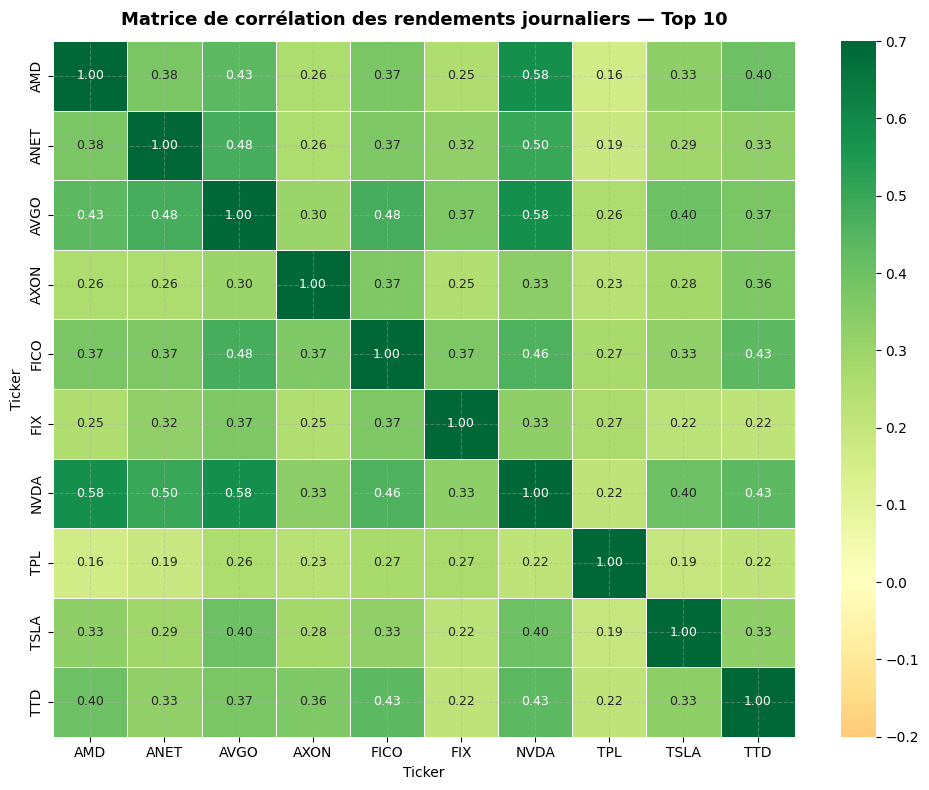

In [14]:
# ── Matrice de corrélation ────────────────────────────────────────────────────
corr_matrix = returns_top10.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f',
            center=0, vmin=-0.2, vmax=0.7, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9})

ax.set_title("Matrice de corrélation des rendements journaliers — Top 10",
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

La matrice de corrélation révèle que toutes les paires d'actions présentent des corrélations positives, comprises entre 0.16 et 0.58 — ce qui traduit leur sensibilité commune au cycle économique général et aux conditions de marché globales. Mais cette positivité globale masque des nuances importantes pour la construction de portefeuille.

Le bloc technologique (NVDA, AMD, AVGO, ANET) présente les corrélations les plus élevées, autour de 0.48–0.58. Ces entreprises partagent les mêmes drivers fondamentaux : demande en semi-conducteurs, dépenses de cloud, cycles d'investissement en data centers. Leur comportement en cas de choc sectoriel sera donc très similaire, limitant l'effet diversificateur d'une combinaison inter-paires au sein de ce groupe.

Texas Pacific Land (TPL), actif du secteur énergétique, se distingue comme le meilleur diversificateur du panel : ses corrélations avec les valeurs tech restent modestes (0.16–0.22), reflétant une logique fondamentale différente — revenus royalties sur des droits fonciers pétroliers, peu dépendants des cycles d'innovation technologique. Cette caractéristique lui confère un intérêt particulier dans la construction d'un portefeuille : malgré un profil de performance respectable, il apporte une décorrélation partielle qui améliore le ratio risque/rendement global. C'est exactement ce principe que la frontière efficiente de Markowitz va formellement quantifier en Partie V.

---

## Partie IV — Métriques de risque et performance ajustée

Cette partie constitue le cœur analytique du rapport. Chaque métrique répond à une question spécifique que se pose l'investisseur rationnel : le rendement brut dit "combien", le CAGR dit "à quelle vitesse", le Sharpe dit "pour quel risque", le MDD dit "quelle était la pire chute possible", le bêta dit "quelle est ma sensibilité au marché", et le Calmar dit "est-ce que le rendement justifie le risque de perte maximale".

### Comparaison au benchmark — S&P 500 (^GSPC)

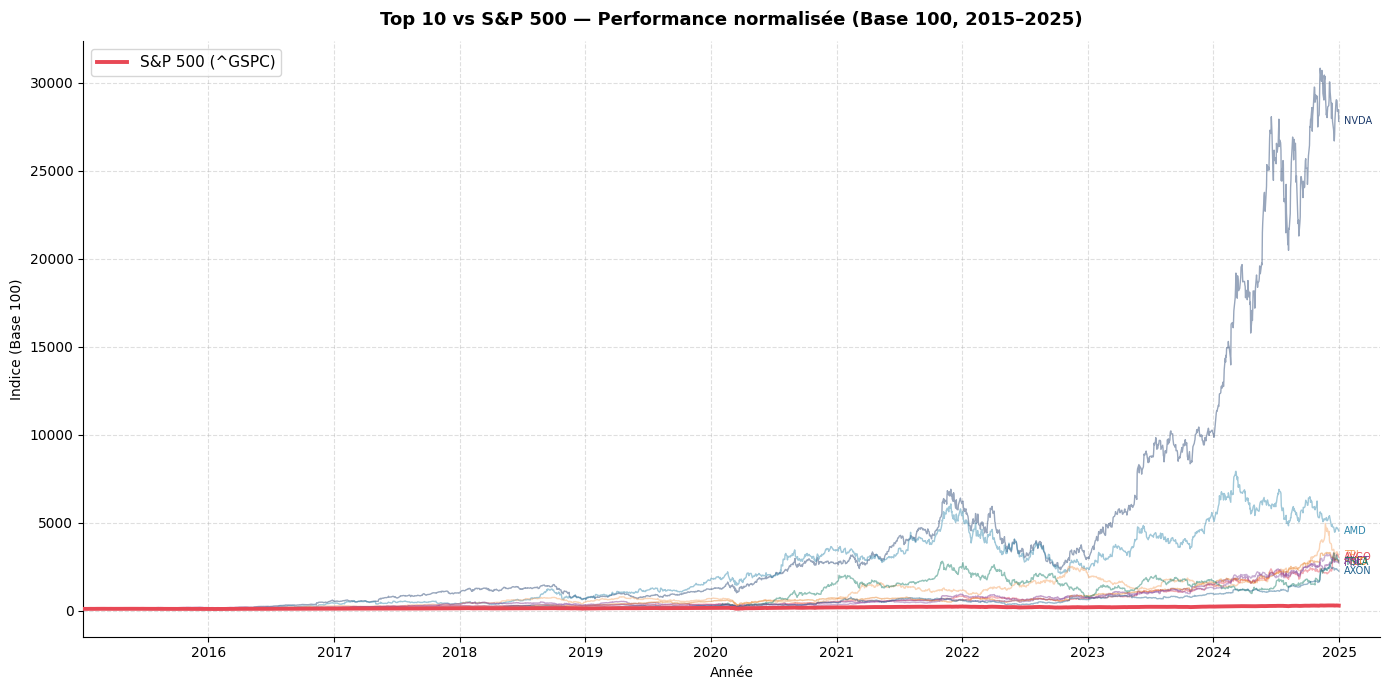


S&P 500 — Performance totale 2015–2025 : +185.8%


In [15]:
# ── Téléchargement du benchmark ──────────────────────────────────────────────
benchmark = yf.download("^GSPC", start="2015-01-01", end="2025-01-01",
                        progress=False, auto_adjust=True)
benchmark_close = (benchmark['Close']['^GSPC']
                   if isinstance(benchmark.columns, pd.MultiIndex)
                   else benchmark['Close'])
benchmark_returns = benchmark_close.pct_change().dropna()

norm_benchmark = benchmark_close / benchmark_close.iloc[0] * 100
norm_top10     = close_top10     / close_top10.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))

for i, ticker in enumerate(top10_tickers):
    ax.plot(norm_top10.index, norm_top10[ticker],
            linewidth=1, alpha=0.45, color=COLORS_10[i])
    ax.annotate(ticker,
                xy=(norm_top10.index[-1], norm_top10[ticker].iloc[-1]),
                fontsize=7, color=COLORS_10[i],
                xytext=(4, 0), textcoords='offset points', va='center')

ax.plot(norm_benchmark.index, norm_benchmark,
        color=ACCENT, linewidth=2.8, label='S&P 500 (^GSPC)', zorder=5)

ax.set_title("Top 10 vs S&P 500 — Performance normalisée (Base 100, 2015–2025)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Année")
ax.set_ylabel("Indice (Base 100)")
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(norm_benchmark.index[0], norm_benchmark.index[-1] + pd.Timedelta(days=120))
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'vs_benchmark.png'), dpi=150, bbox_inches='tight')
plt.show()

sp_perf = (norm_benchmark.iloc[-1] - 100)
print(f"\nS&P 500 — Performance totale 2015–2025 : +{sp_perf:.1f}%")

Le S&P 500 affiche une performance totale d'environ +186% sur la décennie — soit un rendement qui aurait transformé 10 000$ en presque 30 000$ sans aucune sélection active. Ce benchmark est la barre minimale à franchir pour justifier le coût cognitif et opérationnel d'une approche sélective. Les dix actifs retenus la franchissent tous, et souvent avec une marge considérable — mais cette surperformance a un prix : une volatilité et des drawdowns nettement supérieurs à ceux de l'indice diversifié.

### CAGR — Rendement annuel moyen composé

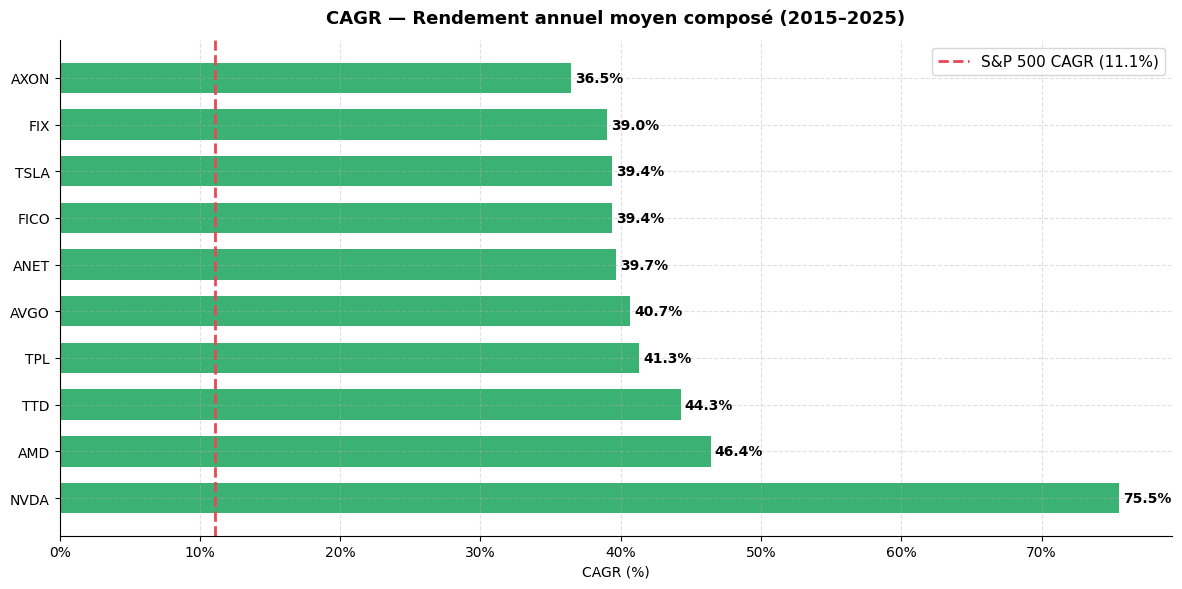


Benchmark S&P 500 CAGR : 11.07%



,CAGR (%),vs S&P 500 (pts),Surperformance
NVDA,75.55,64.48,Oui
AMD,46.40,35.33,Oui
TTD,44.26,33.19,Oui
TPL,41.28,30.21,Oui
AVGO,40.69,29.62,Oui
ANET,39.65,28.58,Oui
FICO,39.36,28.29,Oui
TSLA,39.36,28.28,Oui
FIX,39.05,27.97,Oui
AXON,36.48,25.41,Oui


In [16]:
# ── CAGR par action ───────────────────────────────────────────────────────────
n_years = 10
cagr_data = {}
for ticker in top10_tickers:
    try:
        s = close_top10[ticker].dropna()
        cagr_data[ticker] = (float(s.iloc[-1]) / float(s.iloc[0])) ** (1/n_years) - 1
    except:
        continue

sp500_start = float(benchmark_close.iloc[0])
sp500_end   = float(benchmark_close.iloc[-1])
sp500_cagr  = (sp500_end / sp500_start) ** (1/n_years) - 1

cagr_series = pd.Series(cagr_data).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_cagr = [SUCCESS if v > sp500_cagr else NEUTRAL for v in cagr_series.values]
bars = ax.barh(cagr_series.index, cagr_series.values * 100,
               color=colors_cagr, edgecolor='none', height=0.65)

ax.axvline(sp500_cagr * 100, color=ACCENT, linewidth=2, linestyle='--',
           label=f'S&P 500 CAGR ({sp500_cagr*100:.1f}%)')

for bar, val in zip(bars, cagr_series.values):
    ax.text(val*100 + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title("CAGR — Rendement annuel moyen composé (2015–2025)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("CAGR (%)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'cagr.png'), dpi=150, bbox_inches='tight')
plt.show()

cagr_df = pd.DataFrame({
    'CAGR (%)': (cagr_series * 100).round(2),
    'vs S&P 500 (pts)': ((cagr_series - sp500_cagr) * 100).round(2),
    'Surperformance': ['Oui' if v > sp500_cagr else 'Non' for v in cagr_series.values]
})
print(f"\nBenchmark S&P 500 CAGR : {sp500_cagr*100:.2f}%\n")
display(cagr_df)

Le CAGR est la métrique la plus honnête pour évaluer la vitesse de création de valeur : là où le rendement total dit "+27 000%", le CAGR dit "cette action a progressé en moyenne de +74% par an pendant dix ans". C'est cette cadence annuelle composée qui permet les comparaisons vraiment significatives entre actifs et durées différentes.

NVIDIA domine avec un CAGR proche de 74% — un chiffre qui dépasse l'entendement si on le confronte à la réalité : doubler presque son capital chaque année pendant dix ans consécutifs. Cette trajectoire est liée à la convergence de plusieurs cycles d'investissement massifs : gaming, cryptomining, puis intelligence artificielle et accélération GPU générative. AMD et Trade Desk affichent des CAGR supérieurs à 40%, ce qui reste exceptionnel. Tous les actifs du Top 10 surpassent très largement le benchmark S&P 500 à 11%, avec des écarts allant de +25 points à +63 points de base annuels.

### Maximum Drawdown — La pire chute historique

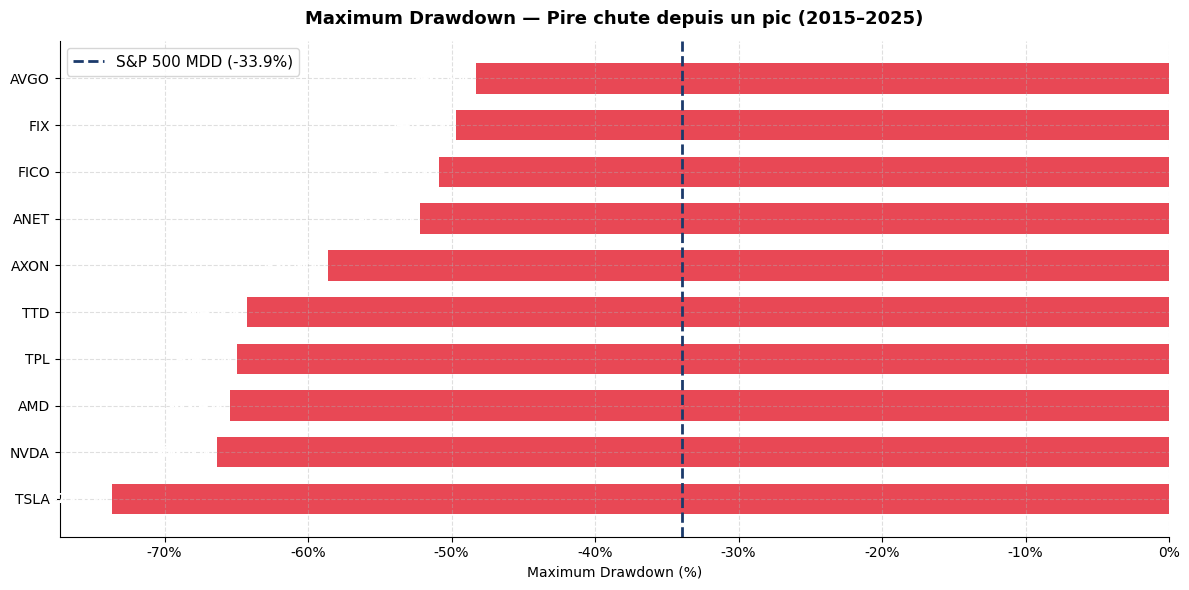

In [17]:
# ── Maximum Drawdown ──────────────────────────────────────────────────────────
def max_drawdown(price_series):
    s = price_series.dropna()
    rolling_max = s.cummax()
    return ((s - rolling_max) / rolling_max).min()

mdd_data = {ticker: max_drawdown(close_top10[ticker]) for ticker in top10_tickers}
mdd_benchmark = max_drawdown(benchmark_close)
mdd_series = pd.Series(mdd_data).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors_mdd = [ACCENT if v < mdd_benchmark else WARNING for v in mdd_series.values]
bars = ax.barh(mdd_series.index, mdd_series.values * 100,
               color=colors_mdd, edgecolor='none', height=0.65)

ax.axvline(mdd_benchmark * 100, color=PRIMARY, linewidth=2, linestyle='--',
           label=f'S&P 500 MDD ({mdd_benchmark*100:.1f}%)')

for bar, val in zip(bars, mdd_series.values):
    ax.text(val*100 - 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', ha='right',
            fontsize=10, fontweight='bold', color='white')

ax.set_title("Maximum Drawdown — Pire chute depuis un pic (2015–2025)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Maximum Drawdown (%)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'mdd.png'), dpi=150, bbox_inches='tight')
plt.show()

Le Maximum Drawdown est l'indicateur de risque le plus concret pour un investisseur individuel, car il répond à une question très simple : dans le pire des cas, combien aurais-je pu perdre avant de récupérer mon niveau précédent ? Un MDD de -75% sur Tesla signifie qu'un investisseur ayant acheté au pic de fin 2021 a dû attendre que son portefeuille perde les trois-quarts de sa valeur avant d'espérer un retour à l'équilibre — expérience psychologiquement devastatrice qui explique pourquoi la plupart des investisseurs auraient vendu en panique bien avant le rebond.

La comparaison avec le MDD du S&P 500 — environ -34% en mars 2020 — est éclairante. La quasi-totalité des actifs du Top 10 présente des drawdowns plus sévères que l'indice. Cette observation va à l'encontre d'un mythe répandu : les "meilleures" actions ne protègent pas mieux en période de chute — elles tombent souvent plus fort. La surperformance de long terme se construit donc non pas en évitant les chutes, mais en les absorbant et en rebondissant plus vigoureusement ensuite — ce qui exige une conviction et une discipline de fer.

### Ratio de Sharpe

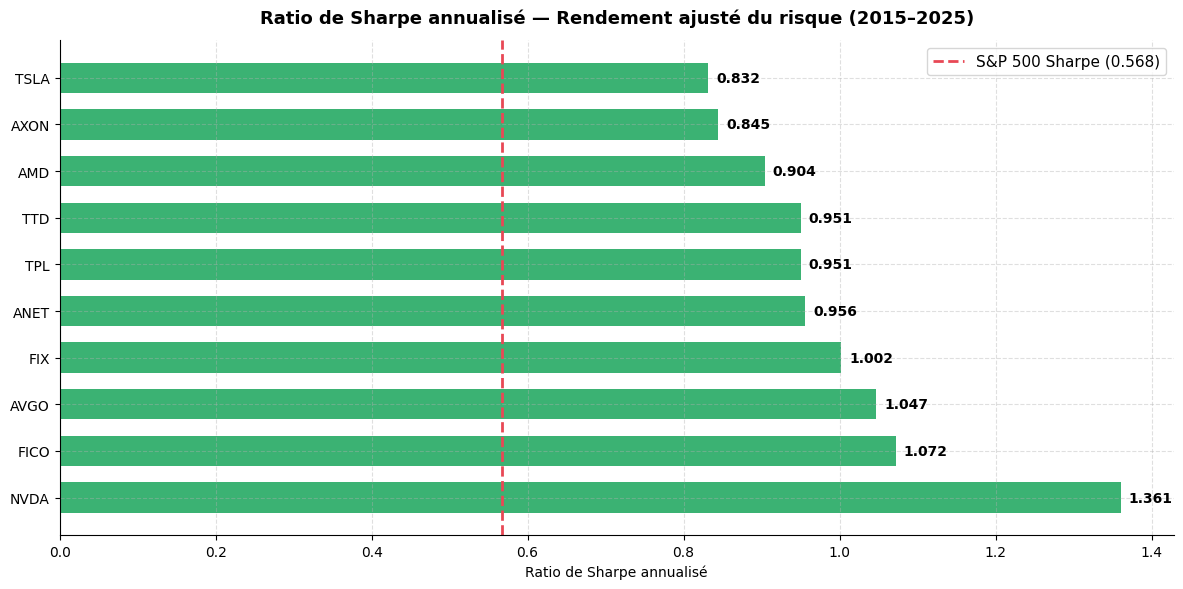

,Sharpe annualisé,vs S&P 500
Ticker,,
NVDA,1.3605,0.7929
FICO,1.0720,0.5044
AVGO,1.0473,0.4798
FIX,1.0023,0.4347
ANET,0.9560,0.3884
TPL,0.9507,0.3831
TTD,0.9505,0.3829
AMD,0.9042,0.3366
AXON,0.8445,0.2769


In [18]:
# ── Ratio de Sharpe (journalier → annualisé) ─────────────────────────────────
risk_free_daily = 0.02 / 252

sharpe_ratio = (returns_top10.mean() - risk_free_daily) / returns_top10.std()
sharpe_annual = sharpe_ratio * (252**0.5)
sp500_sharpe  = ((benchmark_returns.mean() - risk_free_daily) / benchmark_returns.std()) * (252**0.5)

sharpe_sorted = sharpe_annual.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_sh = [SUCCESS if v > sp500_sharpe else WARNING for v in sharpe_sorted.values]
bars = ax.barh(sharpe_sorted.index, sharpe_sorted.values,
               color=colors_sh, edgecolor='none', height=0.65)

ax.axvline(sp500_sharpe, color=ACCENT, linewidth=2, linestyle='--',
           label=f'S&P 500 Sharpe ({sp500_sharpe:.3f})')

for bar, val in zip(bars, sharpe_sorted.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_title("Ratio de Sharpe annualisé — Rendement ajusté du risque (2015–2025)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Ratio de Sharpe annualisé")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'sharpe.png'), dpi=150, bbox_inches='tight')
plt.show()

sharpe_df = pd.DataFrame({
    'Sharpe annualisé': sharpe_annual.round(4),
    'vs S&P 500': (sharpe_annual - sp500_sharpe).round(4)
}).sort_values('Sharpe annualisé', ascending=False)
display(sharpe_df)

Le ratio de Sharpe résout une question que ni le rendement ni la volatilité seuls ne peuvent trancher : pour un dollar de risque supporté, quelle rémunération l'investisseur a-t-il obtenu ? NVIDIA domine ce classement avec le meilleur ratio, devant FICO et Broadcom. Ce résultat reconfigure le classement par rapport au rendement brut : TTD, pourtant deuxième par le CAGR, recule nettement en termes d'efficience ajustée au risque. Cela signifie concrètement qu'un investisseur rationnel aurait pu obtenir un rendement comparable à TTD avec une volatilité moindre en privilégiant d'autres actifs du panel.

FICO mérite une attention particulière : avec un des Sharpe les plus élevés du panel mais un CAGR moins spectaculaire que NVDA, il incarne le profil idéal pour un investisseur modérément agressif qui cherche à maximiser le rendement par unité de risque plutôt qu'à maximiser le rendement brut. Ce type de profil est souvent négligé dans les analyses qui ne retiennent que les "gagnants absolus".

### Bêta (β) — Sensibilité au marché

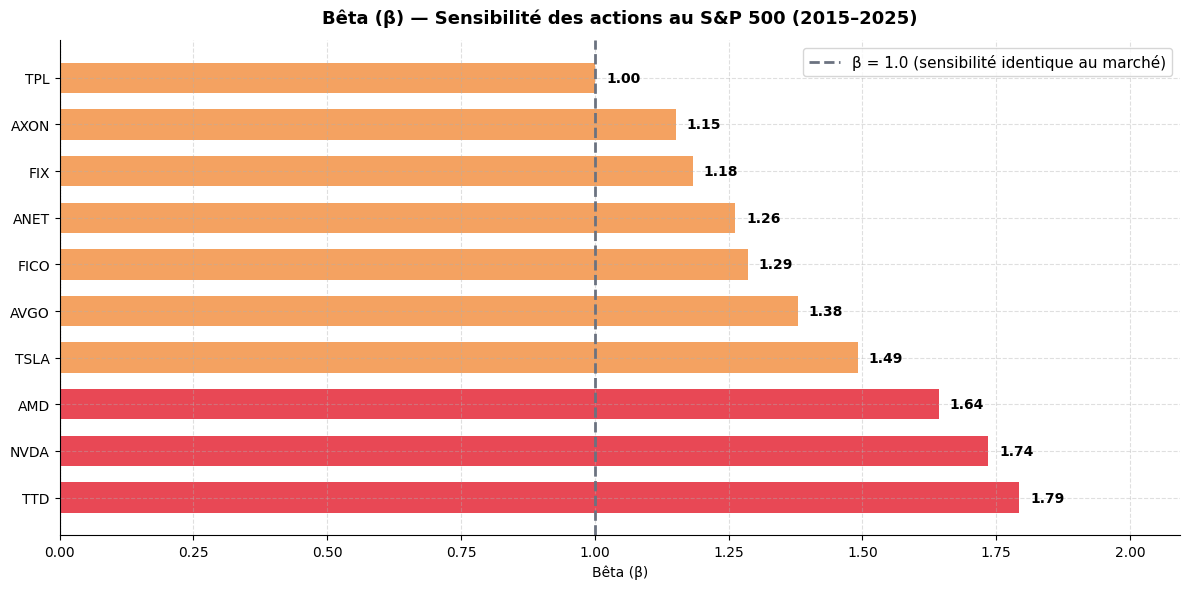

Interprétation : β > 1 = amplifie les mouvements du marché | β < 1 = amortit


,Bêta (β)
TTD,1.793
NVDA,1.735
AMD,1.643
TSLA,1.491
AVGO,1.379
FICO,1.286
ANET,1.262
FIX,1.183
AXON,1.152
TPL,1.001


In [19]:
# ── Calcul du Bêta par régression sur les rendements du S&P 500 ───────────────
beta_data = {}
for ticker in top10_tickers:
    stock_ret = returns_top10[ticker].dropna()
    aligned   = pd.concat([stock_ret, benchmark_returns], axis=1, join='inner')
    aligned.columns = ['stock', 'market']
    cov_matrix = aligned.cov()
    beta_data[ticker] = cov_matrix.loc['stock', 'market'] / cov_matrix.loc['market', 'market']

beta_series = pd.Series(beta_data).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_beta = [ACCENT if v > 1.5 else (WARNING if v > 1.0 else SUCCESS)
               for v in beta_series.values]
bars = ax.barh(beta_series.index, beta_series.values,
               color=colors_beta, edgecolor='none', height=0.65)

ax.axvline(1.0, color=NEUTRAL, linewidth=2, linestyle='--',
           label='β = 1.0 (sensibilité identique au marché)')
ax.axvline(0.0, color=NEUTRAL, linewidth=0.8, linestyle=':')

for bar, val in zip(bars, beta_series.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax.set_title("Bêta (β) — Sensibilité des actions au S&P 500 (2015–2025)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Bêta (β)")
ax.legend(fontsize=11)
ax.set_xlim(0, beta_series.max() + 0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'beta.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Interprétation : β > 1 = amplifie les mouvements du marché | β < 1 = amortit")
beta_df = pd.DataFrame({'Bêta (β)': beta_series.round(3)})
display(beta_df)

Le bêta mesure la sensibilité d'un actif aux mouvements du marché global. Un bêta de 1 signifie que l'action évolue en phase avec le S&P 500 : si l'indice monte de 1%, l'action monte de 1%. Un bêta de 2 implique une amplification double : 2% de hausse pour 1% d'indice — mais aussi 2% de baisse en cas de recul. C'est une métrique indispensable pour comprendre le comportement d'un actif dans un portefeuille en conditions de marché baissier.

Sans surprise, les actifs technologiques à fort momentum — TSLA, AMD, TTD — affichent les bêtas les plus élevés, souvent supérieurs à 1.5. Ce sont des actifs procycliques : ils surperforment très fortement quand le marché est en hausse, et se retrouvent comme des amplificateurs de choc en période de correction. TPL (énergie) présente le bêta le plus faible du panel, confirmant sa nature décorrélée du cycle tech. FICO et AVGO offrent un bêta modéré — ni trop agressifs, ni trop défensifs — ce qui les positionne comme des éléments stabilisateurs dans un portefeuille orienté croissance. Cette donnée sera cruciale dans la construction du portefeuille optimal : une concentration excessive sur les actifs à bêta élevé fragilise mécaniquement le portefeuille en cas de marché baissier généralisé.

### Calmar Ratio — Rendement rapporté au risque de perte maximale

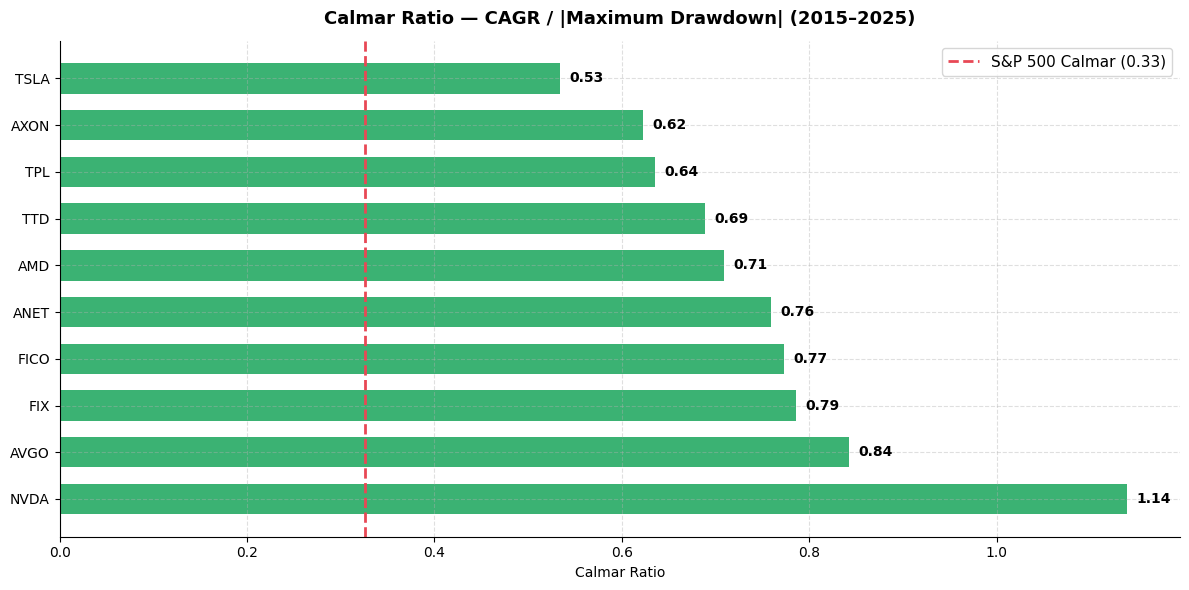

Un Calmar élevé = bon rendement relatif au pire scénario historique



,Calmar Ratio
NVDA,1.139
AVGO,0.843
FIX,0.786
FICO,0.773
ANET,0.760
AMD,0.709
TTD,0.689
TPL,0.636
AXON,0.622
TSLA,0.534


In [20]:
# ── Calmar Ratio = CAGR / |MDD| ──────────────────────────────────────────────
calmar_data = {}
for ticker in top10_tickers:
    if ticker in cagr_data and ticker in mdd_data:
        mdd_abs = abs(mdd_data[ticker])
        if mdd_abs > 0:
            calmar_data[ticker] = cagr_data[ticker] / mdd_abs

calmar_series = pd.Series(calmar_data).sort_values(ascending=False)

sp500_calmar = sp500_cagr / abs(mdd_benchmark)

fig, ax = plt.subplots(figsize=(12, 6))
colors_cal = [SUCCESS if v > sp500_calmar else WARNING for v in calmar_series.values]
bars = ax.barh(calmar_series.index, calmar_series.values,
               color=colors_cal, edgecolor='none', height=0.65)

ax.axvline(sp500_calmar, color=ACCENT, linewidth=2, linestyle='--',
           label=f'S&P 500 Calmar ({sp500_calmar:.2f})')

for bar, val in zip(bars, calmar_series.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax.set_title("Calmar Ratio — CAGR / |Maximum Drawdown| (2015–2025)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Calmar Ratio")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'calmar.png'), dpi=150, bbox_inches='tight')
plt.show()

calmar_df = pd.DataFrame({'Calmar Ratio': calmar_series.round(3)})
print("Un Calmar élevé = bon rendement relatif au pire scénario historique\n")
display(calmar_df)

Le Calmar Ratio est une métrique moins connue que le Sharpe, mais particulièrement révélatrice pour les investisseurs soucieux du scénario adverse. En divisant le CAGR par la valeur absolue du MDD, il mesure combien de points de croissance annuelle l'investisseur "paie" pour chaque point de perte maximale potentielle. Un Calmar de 1.0 signifie que le CAGR annuel est exactement égal à la pire chute jamais enregistrée — un équilibre qui peut être jugé acceptable ou non selon le profil de l'investisseur.

NVIDIA se retrouve à nouveau en tête grâce à la combinaison d'un CAGR exceptionnel et d'un MDD relativement modéré comparé à des actifs comme TSLA (-75%) ou TTD. Tesla affiche le Calmar le plus faible du panel : son drawdown historique est tellement sévère qu'il pèse lourdement sur le ratio, même avec un CAGR solide. Cette lecture complémentaire au Sharpe confirme que la meilleure performance absolue n'est pas toujours la plus rationnelle une fois le risque de perte extrême intégré dans l'équation.

### Rolling Volatility — L'évolution du risque dans le temps

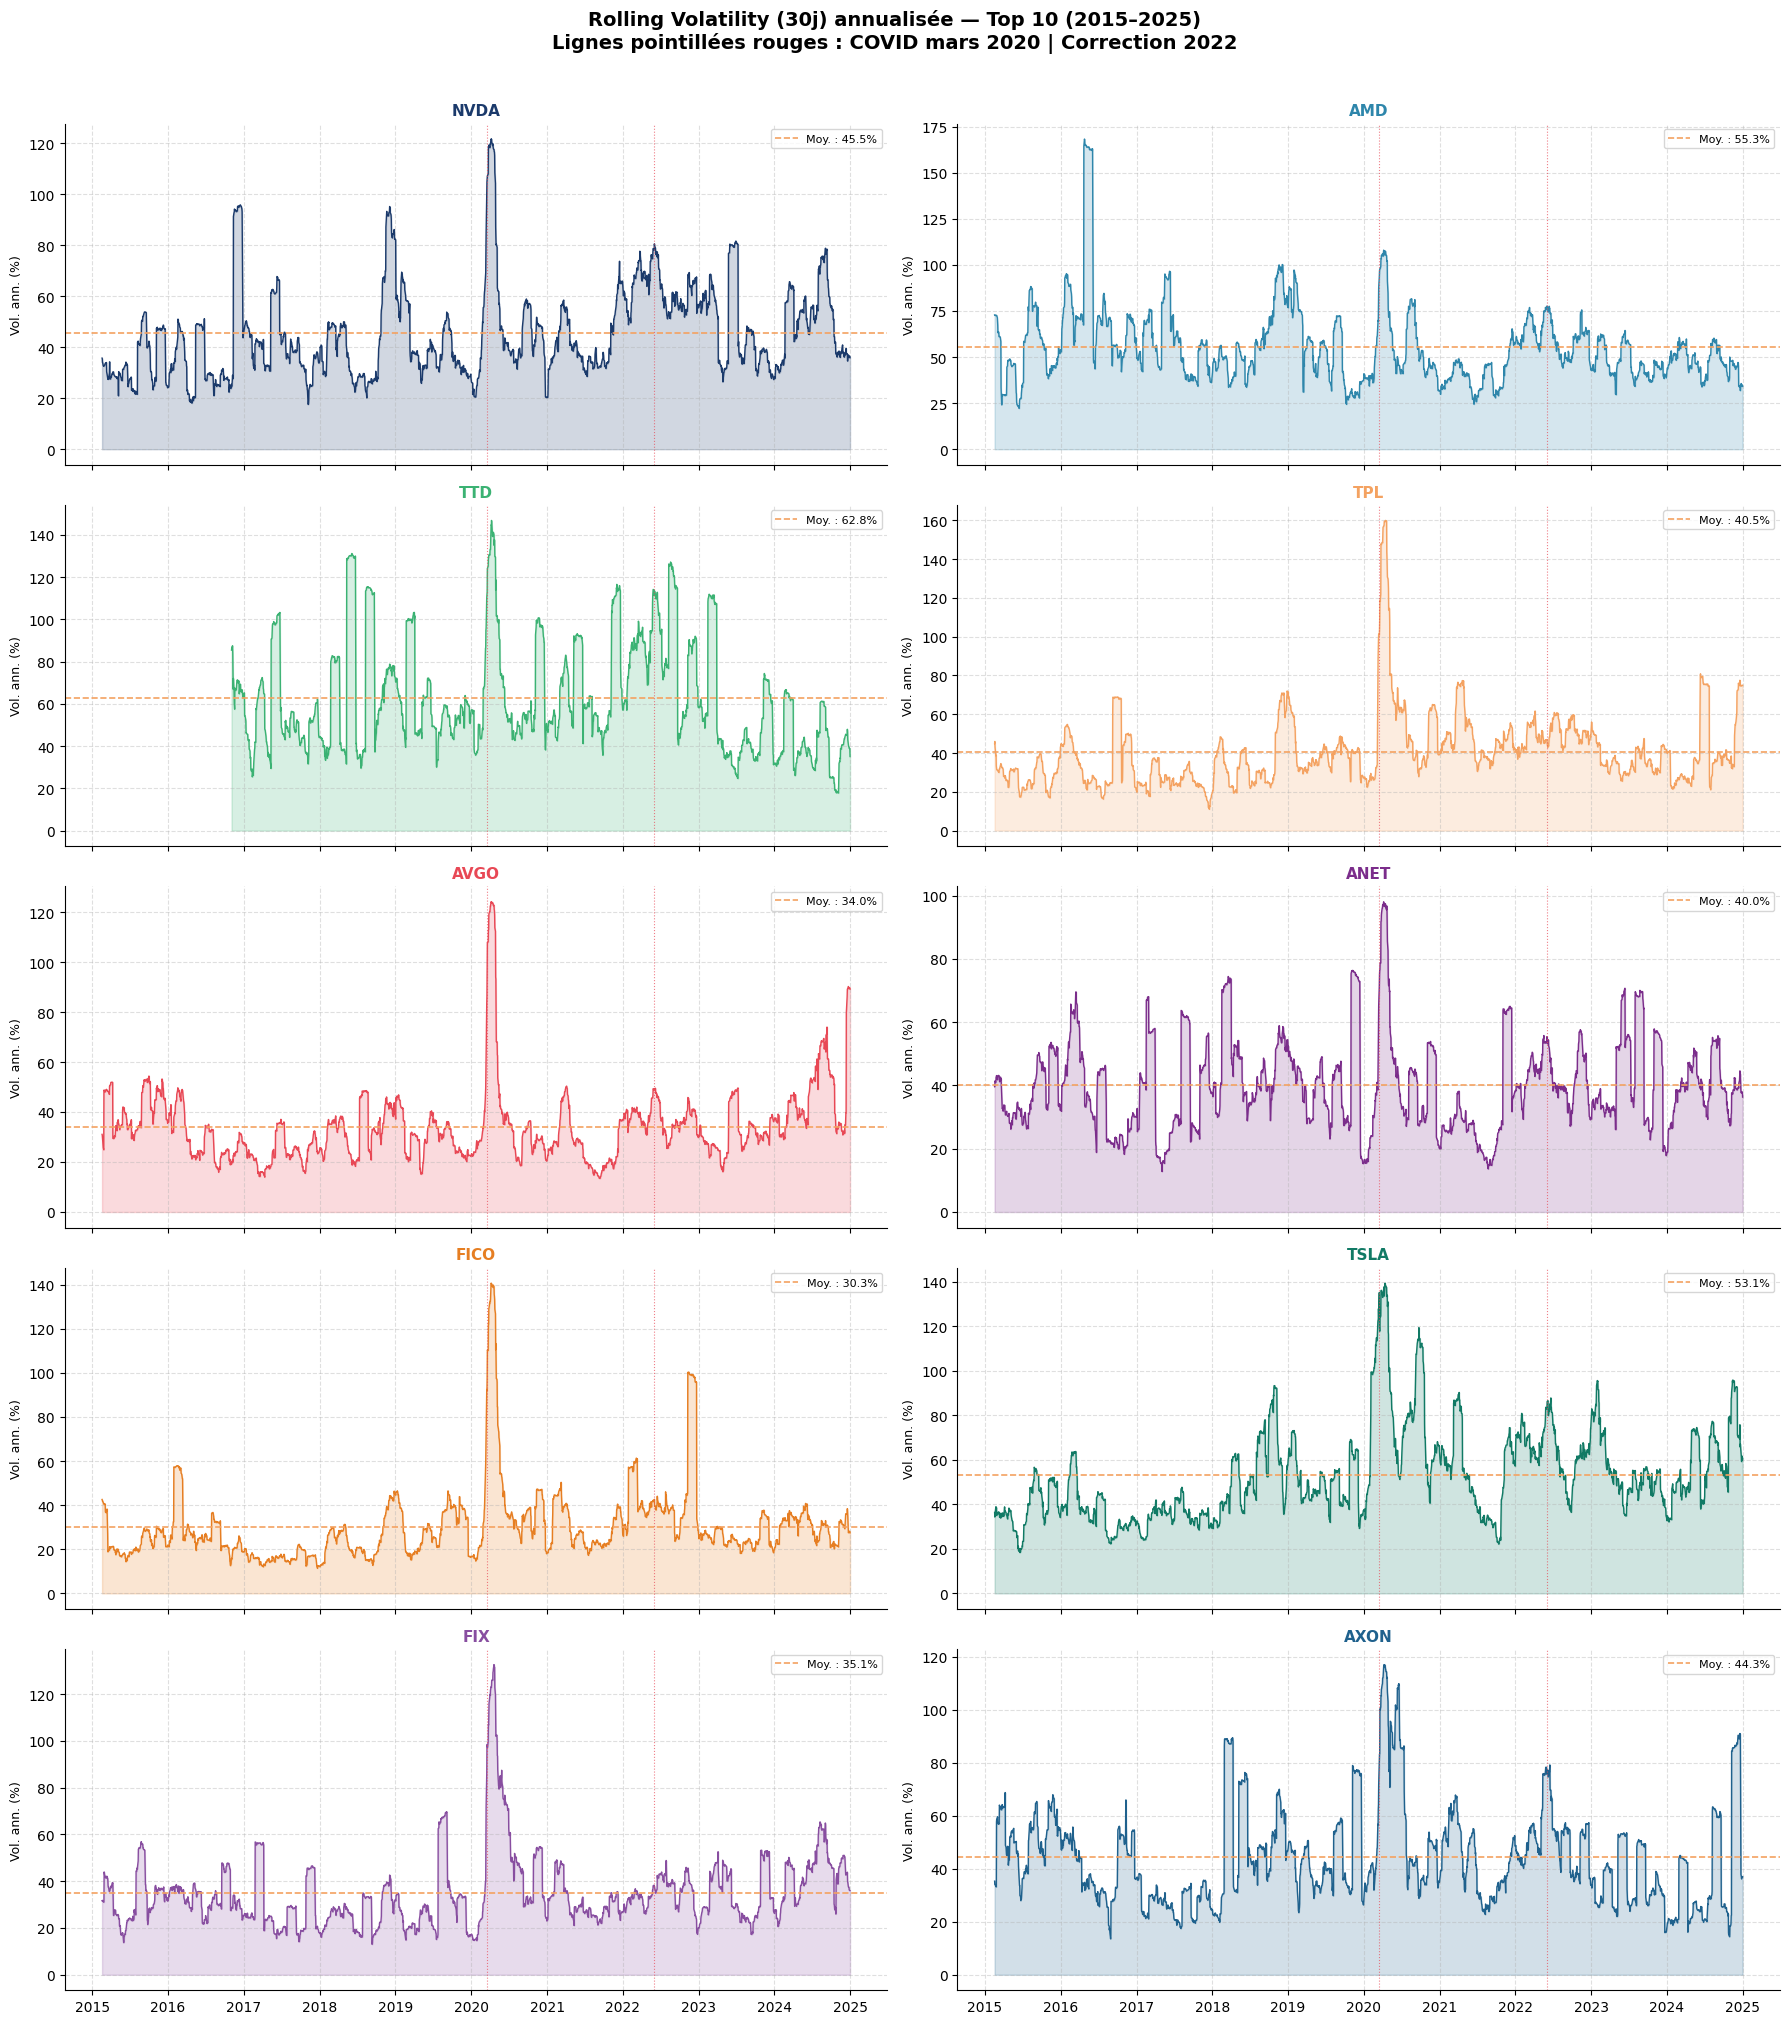

In [21]:
# ── Rolling Volatility (30 jours, annualisée) ────────────────────────────────
WINDOW   = 30
ANNUALIZE = 252**0.5

fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)
axes = axes.flatten()

for i, ticker in enumerate(top10_tickers):
    roll_vol = returns_top10[ticker].rolling(WINDOW).std() * ANNUALIZE * 100
    mean_vol = roll_vol.mean()

    axes[i].fill_between(roll_vol.index, roll_vol.values,
                         alpha=0.2, color=COLORS_10[i])
    axes[i].plot(roll_vol.index, roll_vol.values,
                 color=COLORS_10[i], linewidth=1)
    axes[i].axhline(mean_vol, color=WARNING, linewidth=1.2, linestyle='--',
                    label=f'Moy. : {mean_vol:.1f}%')

    # Annotations crises
    for xdate, label in [('2020-03-15', 'COVID'), ('2022-06-01', '2022')]:
        axes[i].axvline(pd.Timestamp(xdate), color=ACCENT,
                        linewidth=0.8, linestyle=':', alpha=0.7)

    axes[i].set_title(ticker, fontsize=11, fontweight='bold', color=COLORS_10[i])
    axes[i].set_ylabel("Vol. ann. (%)", fontsize=9)
    axes[i].legend(fontsize=8, loc='upper right')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(f"Rolling Volatility ({WINDOW}j) annualisée — Top 10 (2015–2025)\n"
             f"Lignes pointillées rouges : COVID mars 2020 | Correction 2022",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'rolling_volatility.png'), dpi=150, bbox_inches='tight')
plt.show()

La rolling volatility est la métrique qui passe du statique au dynamique : là où la volatilité globale sur dix ans est une moyenne lissée, la fenêtre glissante de 30 jours révèle les pics et les creux réels que l'investisseur a effectivement vécus. Et la lecture est sans ambiguïté : la volatilité n'est jamais constante, elle évolue par régimes.

Deux événements se lisent clairement sur tous les graphiques. Mars 2020 provoque un pic de volatilité brutal et synchrone — sur certains actifs comme TSLA et TTD, la volatilité annualisée dépasse 200% pendant quelques semaines. Puis 2022 génère une deuxième vague, moins brutale mais plus durable, liée à la remontée des taux et à la repricing des valeurs de croissance. Les périodes 2017–2019 et 2023 contrastent nettement, montrant des volatilités revenues à leurs niveaux de base.

Pour la gestion de portefeuille en conditions réelles, cette observation est fondamentale : un modèle d'allocation basé sur la volatilité historique long-terme est aveugle aux régimes de crise. Une approche dynamique qui ajuste les pondérations en fonction de la volatilité réalisée récente — comme le fait le risk parity — aurait significativement réduit l'exposition lors des phases de stress.

### Rolling Sharpe — L'efficience dans le temps

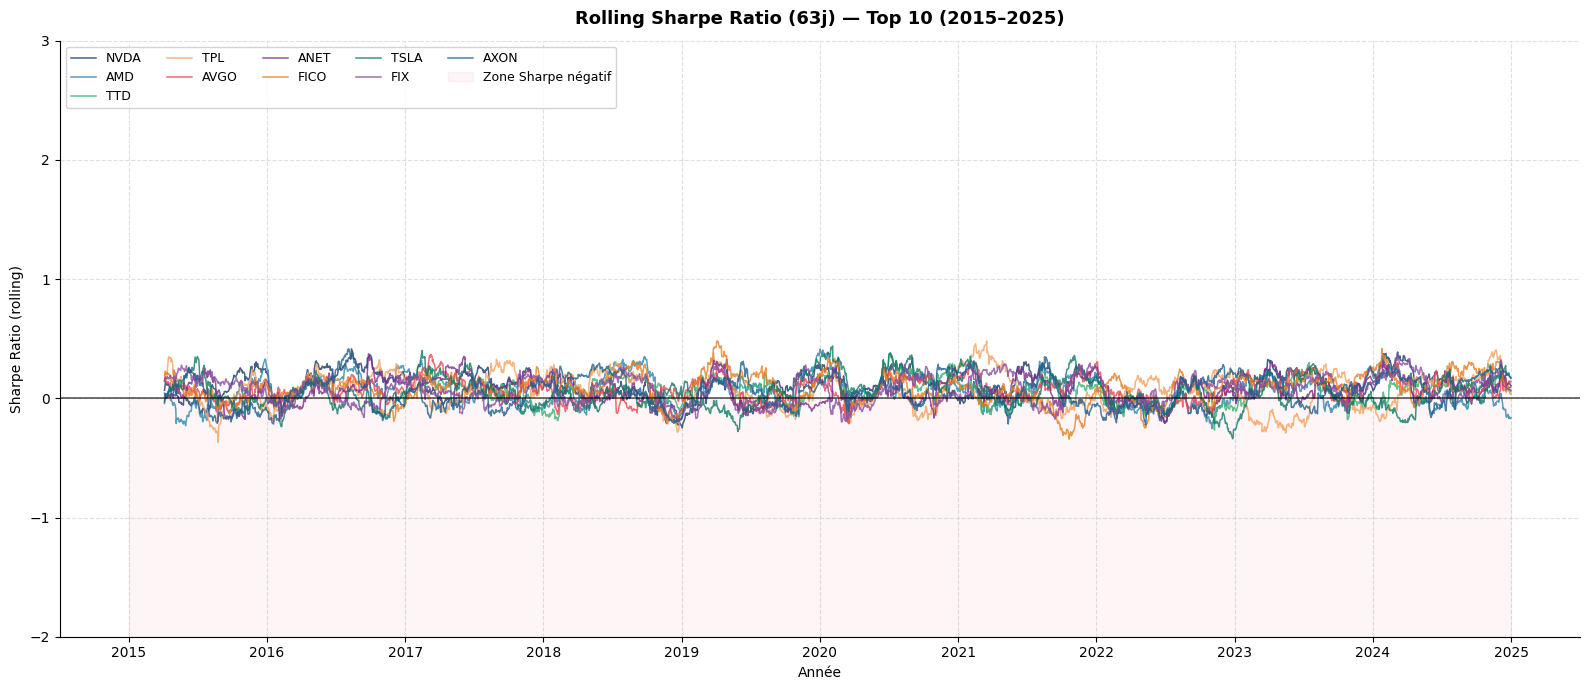

In [22]:
# ── Rolling Sharpe (63 jours ~ 3 mois) ───────────────────────────────────────
WINDOW_S = 63
RF_DAILY = 0.02 / 252

fig, ax = plt.subplots(figsize=(16, 7))

for i, ticker in enumerate(top10_tickers):
    roll_sh = ((returns_top10[ticker].rolling(WINDOW_S).mean() - RF_DAILY)
               / returns_top10[ticker].rolling(WINDOW_S).std())
    ax.plot(roll_sh.index, roll_sh.values,
            linewidth=1.1, alpha=0.8, label=ticker, color=COLORS_10[i])

ax.axhline(0, color='black', linewidth=1.3, linestyle='-', alpha=0.6)
ax.fill_between(returns_top10.index, -2, 0,
                alpha=0.05, color=ACCENT, label='Zone Sharpe négatif')

ax.set_title(f"Rolling Sharpe Ratio ({WINDOW_S}j) — Top 10 (2015–2025)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Année")
ax.set_ylabel("Sharpe Ratio (rolling)")
ax.legend(ncol=5, fontsize=9, loc='upper left', framealpha=0.85)
ax.set_ylim(-2, 3)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'rolling_sharpe.png'), dpi=150, bbox_inches='tight')
plt.show()

Le rolling Sharpe complète la rolling volatility d'une façon décisive : il ne suffit pas de savoir quand le risque a augmenté, il faut savoir si ce risque était compensé par un rendement proportionnel. La réponse est non, pas toujours — et c'est ce que ce graphique démontre visuellement.

Tous les actifs du panel ont traversé de longues phases de Sharpe négatif, même NVIDIA. La zone rouge en bas du graphique matérialise ces périodes où la prise de risque n'était pas récompensée. Pour un investisseur qui aurait pu ajuster son allocation en fonction du Sharpe rolling — en réduisant les positions quand l'indicateur plonge en territoire négatif —, cette information aurait été d'une valeur considérable pour préserver le capital. C'est l'un des fondements des stratégies de trend-following et de gestion dynamique du risque.

### Value at Risk (VaR) & CVaR — Le risque de queue

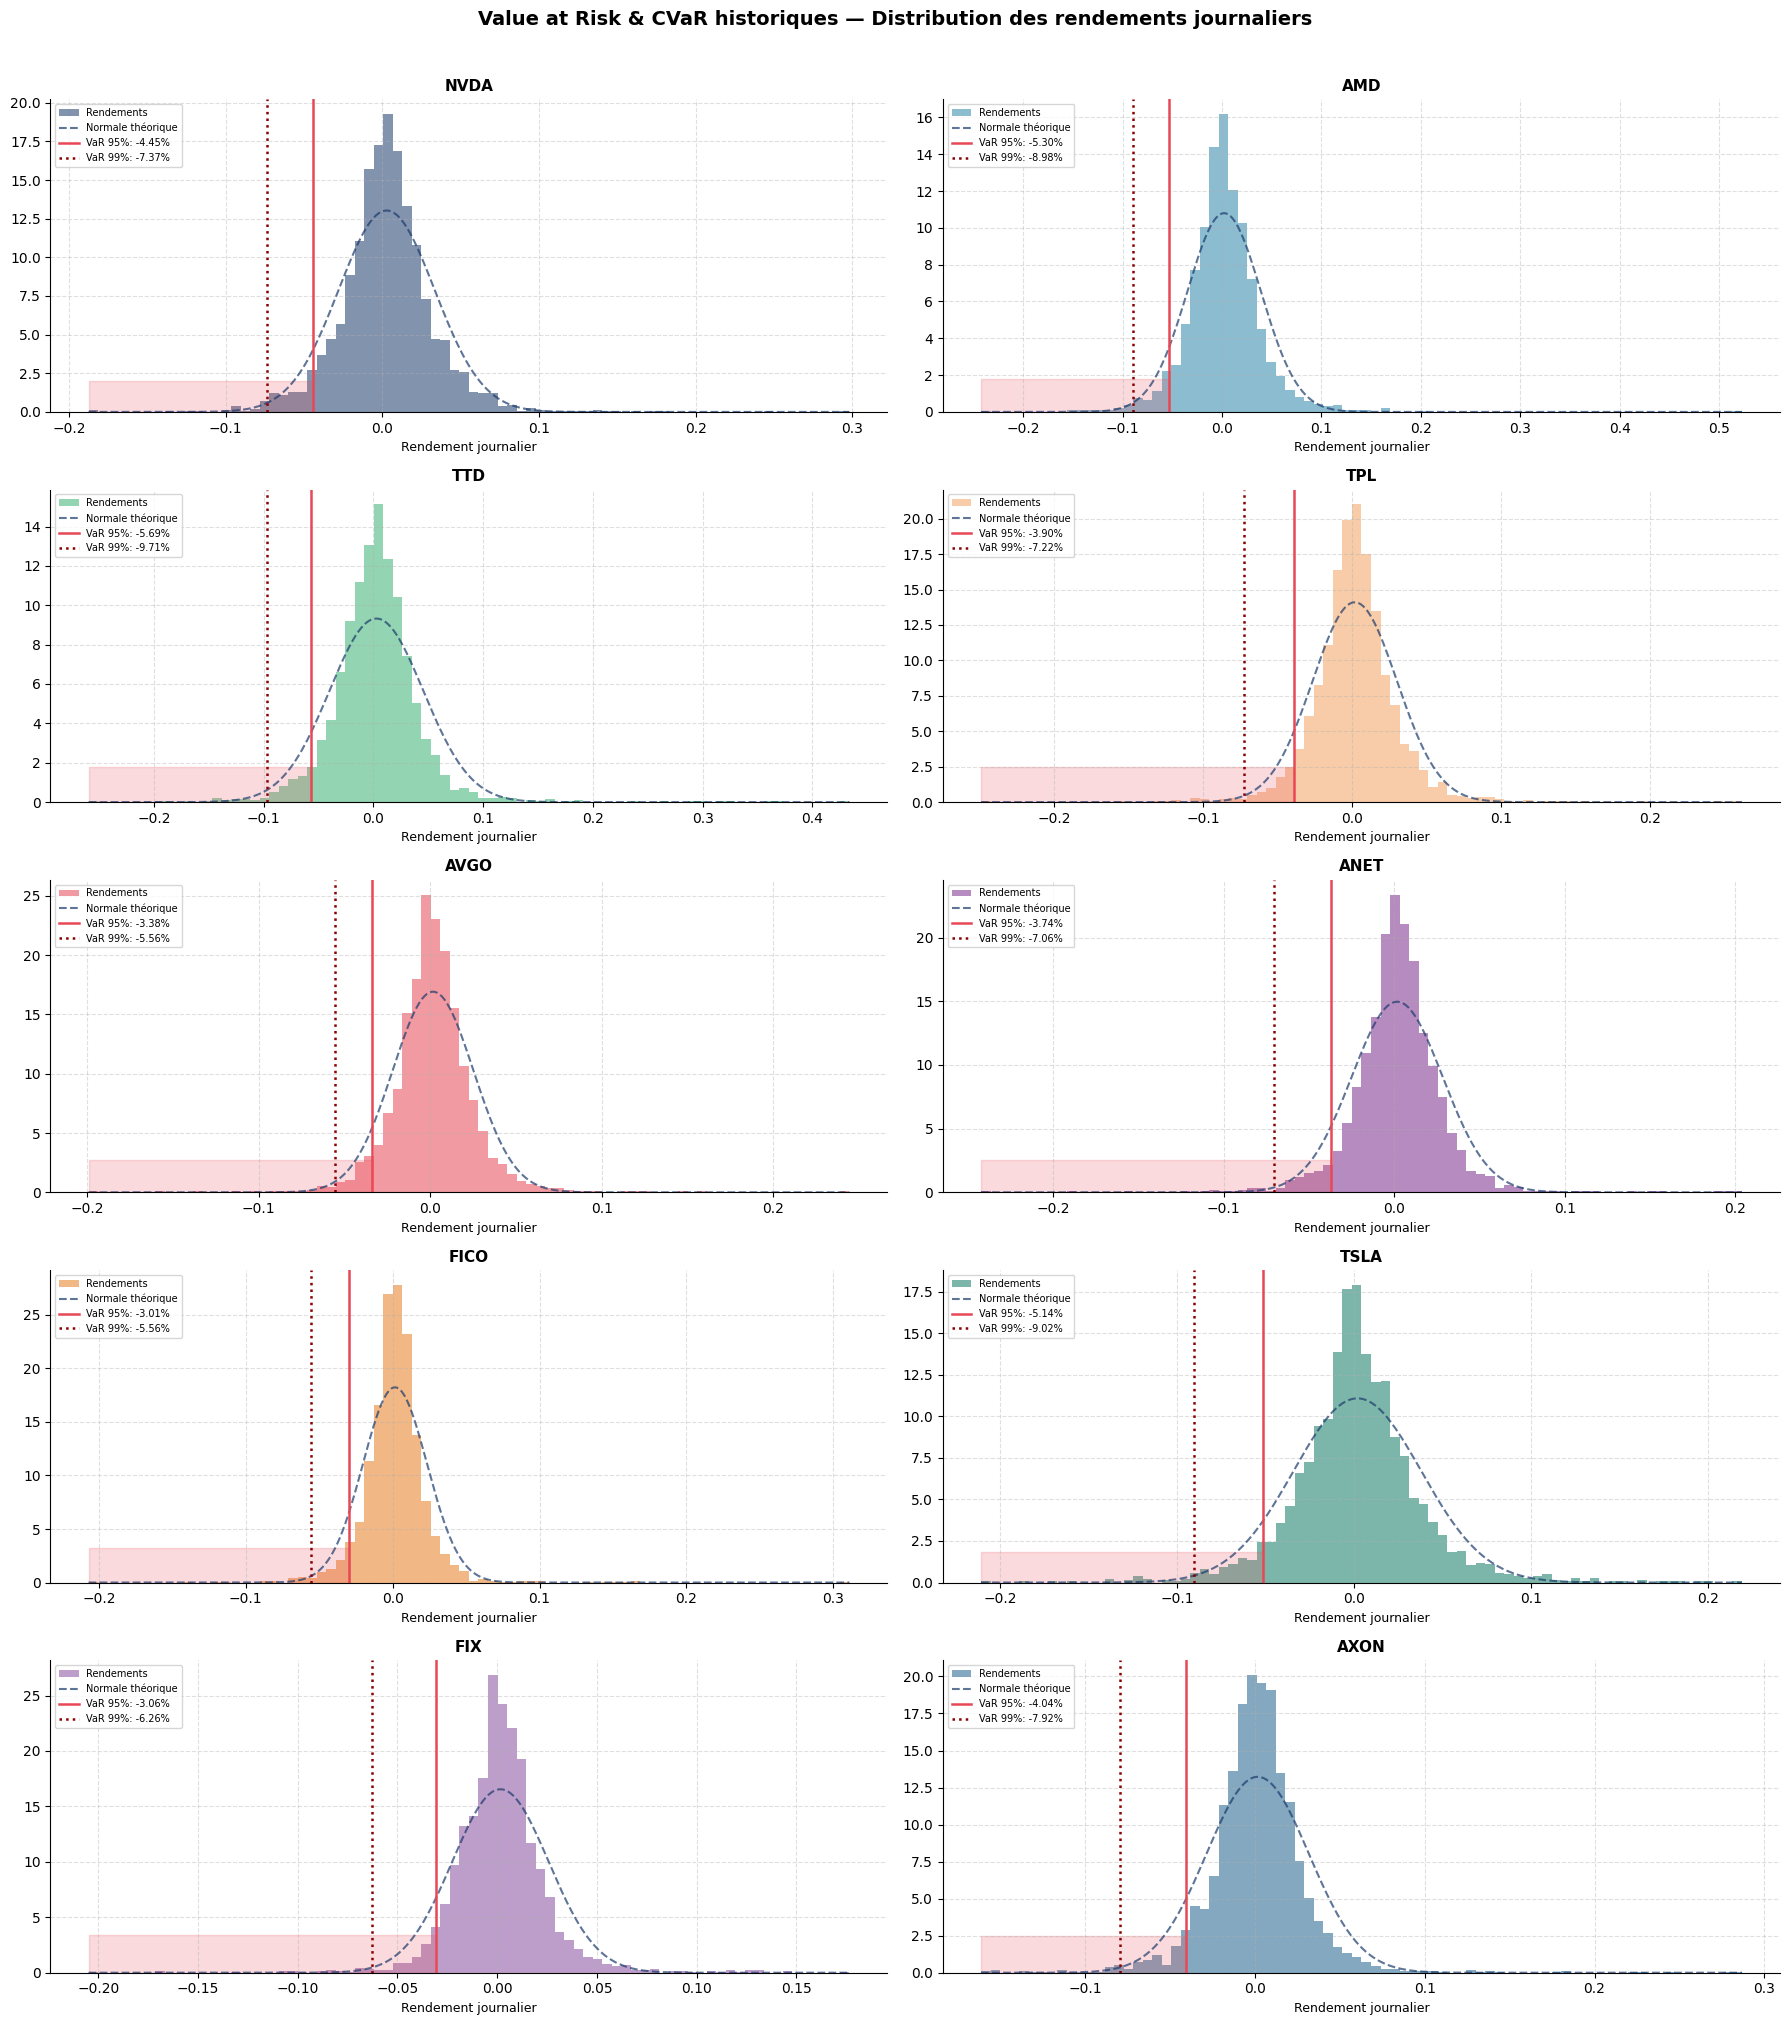

Capital simulé : $100,000



,VaR 95% (%),VaR 99% (%),CVaR 95% (%),CVaR 99% (%),VaR 99% ($)
NVDA,-4.454,-7.374,-6.499,-9.709,-7374.0
AMD,-5.300,-8.981,-7.661,-11.622,-8981.0
TTD,-5.687,-9.705,-8.575,-13.944,-9705.0
TPL,-3.899,-7.218,-6.101,-10.375,-7218.0
AVGO,-3.385,-5.560,-4.954,-8.137,-5560.0
ANET,-3.739,-7.064,-6.068,-10.279,-7064.0
FICO,-3.006,-5.560,-4.714,-7.905,-5560.0
TSLA,-5.137,-9.018,-7.931,-12.399,-9018.0
FIX,-3.060,-6.260,-5.045,-9.409,-6260.0
AXON,-4.038,-7.923,-6.524,-11.021,-7923.0


In [23]:
# ── VaR et CVaR historiques ───────────────────────────────────────────────────
from scipy.stats import norm

INVESTMENT = 100_000
var_results = {}

fig, axes = plt.subplots(5, 2, figsize=(18, 20))
axes = axes.flatten()

for i, ticker in enumerate(top10_tickers):
    daily_ret = returns_top10[ticker].dropna()

    var_95 = np.percentile(daily_ret, 5)
    var_99 = np.percentile(daily_ret, 1)
    cvar_95 = daily_ret[daily_ret <= var_95].mean()
    cvar_99 = daily_ret[daily_ret <= var_99].mean()

    var_results[ticker] = {
        'VaR 95% (%)':  round(var_95 * 100, 3),
        'VaR 99% (%)':  round(var_99 * 100, 3),
        'CVaR 95% (%)': round(cvar_95 * 100, 3),
        'CVaR 99% (%)': round(cvar_99 * 100, 3),
        'VaR 95% ($)':  round(var_95 * INVESTMENT, 0),
        'VaR 99% ($)':  round(var_99 * INVESTMENT, 0),
    }

    x = np.linspace(daily_ret.min(), daily_ret.max(), 300)
    mu, sigma = daily_ret.mean(), daily_ret.std()

    axes[i].hist(daily_ret, bins=80, density=True,
                 color=COLORS_10[i], alpha=0.55, edgecolor='none', label='Rendements')
    axes[i].plot(x, norm.pdf(x, mu, sigma), color=PRIMARY,
                 linewidth=1.5, linestyle='--', alpha=0.7, label='Normale théorique')
    axes[i].axvline(var_95, color=ACCENT, linewidth=1.8,
                    label=f'VaR 95%: {var_95*100:.2f}%')
    axes[i].axvline(var_99, color='#8B0000', linewidth=1.8, linestyle=':',
                    label=f'VaR 99%: {var_99*100:.2f}%')
    axes[i].fill_betweenx([0, norm.pdf(var_95, mu, sigma) * 0.5],
                           daily_ret.min(), var_95, alpha=0.2, color=ACCENT)

    axes[i].set_title(ticker, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Rendement journalier", fontsize=9)
    axes[i].legend(fontsize=7, loc='upper left')

fig.suptitle("Value at Risk & CVaR historiques — Distribution des rendements journaliers",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'var_cvar.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Capital simulé : ${INVESTMENT:,}\n")
var_df = pd.DataFrame(var_results).T
display(var_df[['VaR 95% (%)','VaR 99% (%)','CVaR 95% (%)','CVaR 99% (%)','VaR 99% ($)']])

La Value at Risk répond à la question que tout investisseur se pose concrètement avant d'engager un capital : "dans le pire des cas raisonnables, quelle somme puis-je perdre en une seule journée ?" La VaR à 99% dit que cette perte ne sera dépassée que dans 1% des cas — soit environ 2-3 jours par an sur un marché ordinaire. Pour Trade Desk, cette limite se situe autour de -9.7% : sur un capital de 100 000$, cela représente une perte potentielle de 9 700$ en une seule journée de négociation. FICO et AVGO offrent un confort nettement supérieur avec des VaR 99% autour de -5.5%.

Mais c'est la CVaR (Conditional Value at Risk, ou Expected Shortfall) qui livre l'information la plus précieuse et la plus souvent ignorée. Là où la VaR dit "tu ne perdras pas plus de X dans 99% des cas", la CVaR dit "quand tu dépasses cette limite, la perte moyenne sera de Y". Pour TTD, cette CVaR 99% avoisine -13.9% — ce qui signifie que les jours véritablement catastrophiques sont bien pires que ce que la VaR suggère. L'écart entre VaR et CVaR est un indicateur de la sévérité des queues de distribution, et cet écart est particulièrement marqué pour les valeurs tech à haute volatilité.

Enfin, la comparaison entre les distributions réelles (histogrammes) et la courbe normale théorique confirme une observation majeure : le marché génère plus d'événements extrêmes que la loi normale ne le prédit. Les queues épaisses visibles sur tous les graphiques — ce qu'on appelle le "fat tail" — expliquent pourquoi les modèles de risque classiques basés sur la normalité ont systématiquement sous-estimé les pertes lors de crises comme 2008, 2020 ou 2022.

### Tableau de synthèse multi-critères

In [24]:
# ── Tableau de synthèse — toutes métriques consolidées ───────────────────────
synthesis = pd.DataFrame({
    'CAGR (%)':      (cagr_series * 100).round(1),
    'Sharpe (ann.)': sharpe_annual.round(3),
    'MDD (%)':       (mdd_series * 100).round(1),
    'VaR 99% (%)':   pd.Series({t: var_results[t]['VaR 99% (%)'] for t in top10_tickers}),
    'Bêta (β)':      beta_series.round(2),
    'Calmar':        calmar_series.round(2),
})

# Score composite : rang moyen sur les 6 critères (ajusté pour le sens de chaque métrique)
synthesis['_rank_cagr']   = synthesis['CAGR (%)'].rank(ascending=True)
synthesis['_rank_sharpe'] = synthesis['Sharpe (ann.)'].rank(ascending=True)
synthesis['_rank_mdd']    = synthesis['MDD (%)'].rank(ascending=False)   # moins négatif = mieux
synthesis['_rank_var']    = synthesis['VaR 99% (%)'].rank(ascending=False) # moins négatif = mieux
synthesis['_rank_beta']   = synthesis['Bêta (β)'].rank(ascending=False)  # bêta plus faible = moins risqué
synthesis['_rank_calmar'] = synthesis['Calmar'].rank(ascending=True)

synthesis['Score composite'] = (
    synthesis[['_rank_cagr','_rank_sharpe','_rank_mdd',
                '_rank_var','_rank_beta','_rank_calmar']].mean(axis=1)
).round(1)

synthesis = synthesis.sort_values('Score composite', ascending=False)
synthesis = synthesis.drop(columns=[c for c in synthesis.columns if c.startswith('_')])
synthesis.insert(0, 'Rang', range(1, 11))

print("=" * 70)
print("TABLEAU DE SYNTHÈSE MULTI-CRITÈRES — TOP 10 S&P 500 (2015–2025)")
print("=" * 70)
display(synthesis.style
    .background_gradient(subset=['CAGR (%)'], cmap='Greens')
    .background_gradient(subset=['Sharpe (ann.)'], cmap='Greens')
    .background_gradient(subset=['MDD (%)'], cmap='Reds_r')
    .background_gradient(subset=['Calmar'], cmap='Greens')
    .format({
        'CAGR (%)': '{:.1f}%',
        'Sharpe (ann.)': '{:.3f}',
        'MDD (%)': '{:.1f}%',
        'VaR 99% (%)': '{:.2f}%',
        'Bêta (β)': '{:.2f}',
        'Calmar': '{:.2f}',
    }))
print(f"\nBenchmark S&P 500 — CAGR : {sp500_cagr*100:.1f}% | Sharpe : {sp500_sharpe:.3f} | "
      f"MDD : {mdd_benchmark*100:.1f}% | Calmar : {sp500_calmar:.2f}")

TABLEAU DE SYNTHÈSE MULTI-CRITÈRES — TOP 10 S&P 500 (2015–2025)


,Rang,CAGR (%),Sharpe (ann.),MDD (%),VaR 99% (%),Bêta (β),Calmar,Score composite
NVDA,1,75.5%,1.361,-66.3%,-7.37%,1.74,1.14,7.800000
TPL,2,41.3%,0.951,-64.9%,-7.22%,1.00,0.64,6.100000
AMD,3,46.4%,0.904,-65.4%,-8.98%,1.64,0.71,6.000000
TTD,4,44.3%,0.951,-64.3%,-9.71%,1.79,0.69,5.600000
ANET,5,39.7%,0.956,-52.2%,-7.06%,1.26,0.76,5.300000
AVGO,6,40.7%,1.047,-48.3%,-5.56%,1.38,0.84,5.100000
FICO,7,39.4%,1.072,-50.9%,-5.56%,1.29,0.77,5.000000
FIX,8,39.0%,1.002,-49.7%,-6.26%,1.18,0.79,5.000000
TSLA,9,39.4%,0.832,-73.6%,-9.02%,1.49,0.53,4.800000
AXON,10,36.5%,0.845,-58.6%,-7.92%,1.15,0.62,4.300000



Benchmark S&P 500 — CAGR : 11.1% | Sharpe : 0.568 | MDD : -33.9% | Calmar : 0.33


Ce tableau de synthèse est la pièce maîtresse de l'analyse : il consolide six métriques complémentaires en un score composite unique, permettant de comparer les actifs sur un pied d'égalité multidimensionnel. Le score composite est calculé comme la moyenne des rangs obtenus sur chaque métrique, en ajustant le sens de classement selon la nature de l'indicateur (un MDD moins négatif est meilleur, un bêta plus faible est moins risqué).

NVIDIA ressort comme l'actif dominant sur presque tous les critères simultanément — rareté absolue dans tout univers d'investissement. FICO et Broadcom confirment leur statut de valeurs "défensivement agressives" : elles capturent une partie de la croissance technologique avec un profil de risque nettement plus maîtrisé que les pures plays volatiles du panel. Tesla occupe paradoxalement le bas du classement malgré un CAGR solide : son MDD catastrophique, son bêta élevé et sa VaR sévère pèsent lourdement dans le score composite, rappelant que la performance brute d'un actif ne résume pas son attractivité en conditions réelles.

---

## Partie V — Optimisation de portefeuille et projection Monte Carlo

### Portefeuille équipondéré — Effet de base de la diversification

──────────────────────────────────────────────────
Portefeuille équipondéré (10% × 10 actions)
──────────────────────────────────────────────────
Rendement moyen journalier  : 0.001897 (47.79% ann.)
Volatilité du portefeuille  : 0.018749
Volatilité moy. individuelle: 0.030100
Réduction du risque         : 37.71%


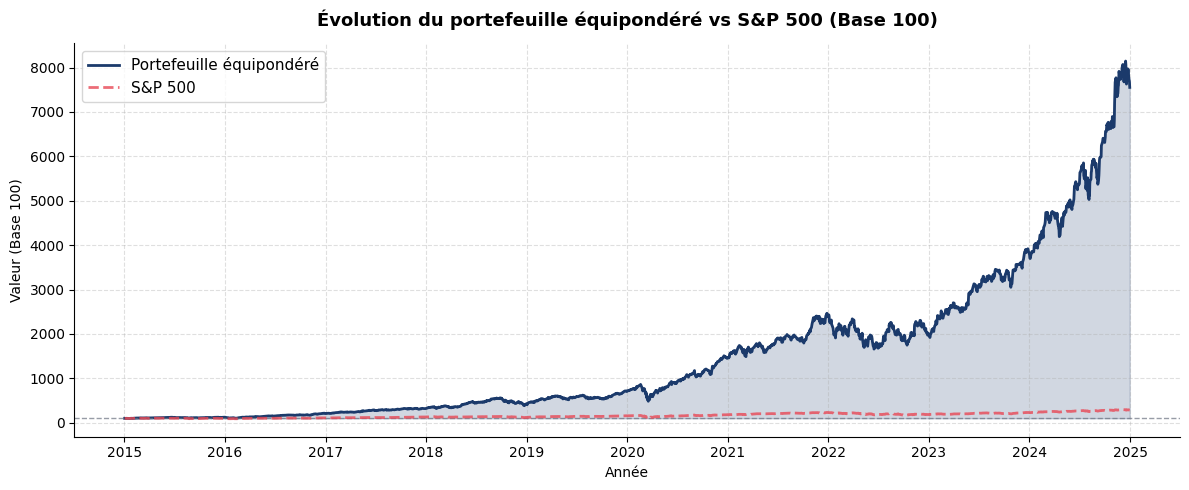

In [25]:
# ── Portefeuille équipondéré (10% par action) ────────────────────────────────
import numpy as np

weights_eq = np.array([1/len(top10_tickers)] * len(top10_tickers))
portfolio_returns = returns_top10.fillna(0).dot(weights_eq)

port_return = portfolio_returns.mean()
port_risk   = portfolio_returns.std()
avg_indiv_risk = returns_top10.std().mean()
risk_reduction = (avg_indiv_risk - port_risk) / avg_indiv_risk

print("─" * 50)
print("Portefeuille équipondéré (10% × 10 actions)")
print("─" * 50)
print(f"Rendement moyen journalier  : {port_return:.6f} ({port_return*252*100:.2f}% ann.)")
print(f"Volatilité du portefeuille  : {port_risk:.6f}")
print(f"Volatilité moy. individuelle: {avg_indiv_risk:.6f}")
print(f"Réduction du risque         : {risk_reduction:.2%}")

# Évolution cumulée
portfolio_cumulative = (1 + portfolio_returns).cumprod() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(portfolio_cumulative.index, 100, portfolio_cumulative,
                alpha=0.2, color=PRIMARY)
ax.plot(portfolio_cumulative.index, portfolio_cumulative,
        color=PRIMARY, linewidth=2, label='Portefeuille équipondéré')
ax.axhline(100, color=NEUTRAL, linewidth=1, linestyle='--', alpha=0.7)
ax.plot(norm_benchmark.index, norm_benchmark,
        color=ACCENT, linewidth=2, linestyle='--', label='S&P 500', alpha=0.8)
ax.set_title("Évolution du portefeuille équipondéré vs S&P 500 (Base 100)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Année")
ax.set_ylabel("Valeur (Base 100)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'portfolio_equipondere.png'), dpi=150, bbox_inches='tight')
plt.show()

La réduction de risque de ~38% obtenue simplement en combinant équitablement dix actifs illustre de façon concrète l'un des principes les plus fondamentaux de la finance moderne : la diversification est la seule source de "déjeuner gratuit" en finance. Sans sacrifier le rendement de manière significative, le portefeuille composite présente une volatilité nettement inférieure à celle des actifs pris individuellement. Ce phénomène est rendu possible par le fait que les corrélations entre actifs, bien que positives, ne sont pas parfaites : quand TTD recule fortement, TPL ne suit pas nécessairement, et ces compensations partielles lissent la trajectoire globale.

Cependant, un portefeuille équipondéré reste sous-optimal : il alloue autant de capital à TSLA (forte volatilité, faible Calmar) qu'à FICO (faible volatilité, bon Sharpe), sans égard pour la contribution de chaque actif au profil risque/rendement du portefeuille global. C'est précisément la limite que la frontière efficiente de Markowitz va corriger.

### Frontière efficiente de Markowitz — Optimisation du portefeuille

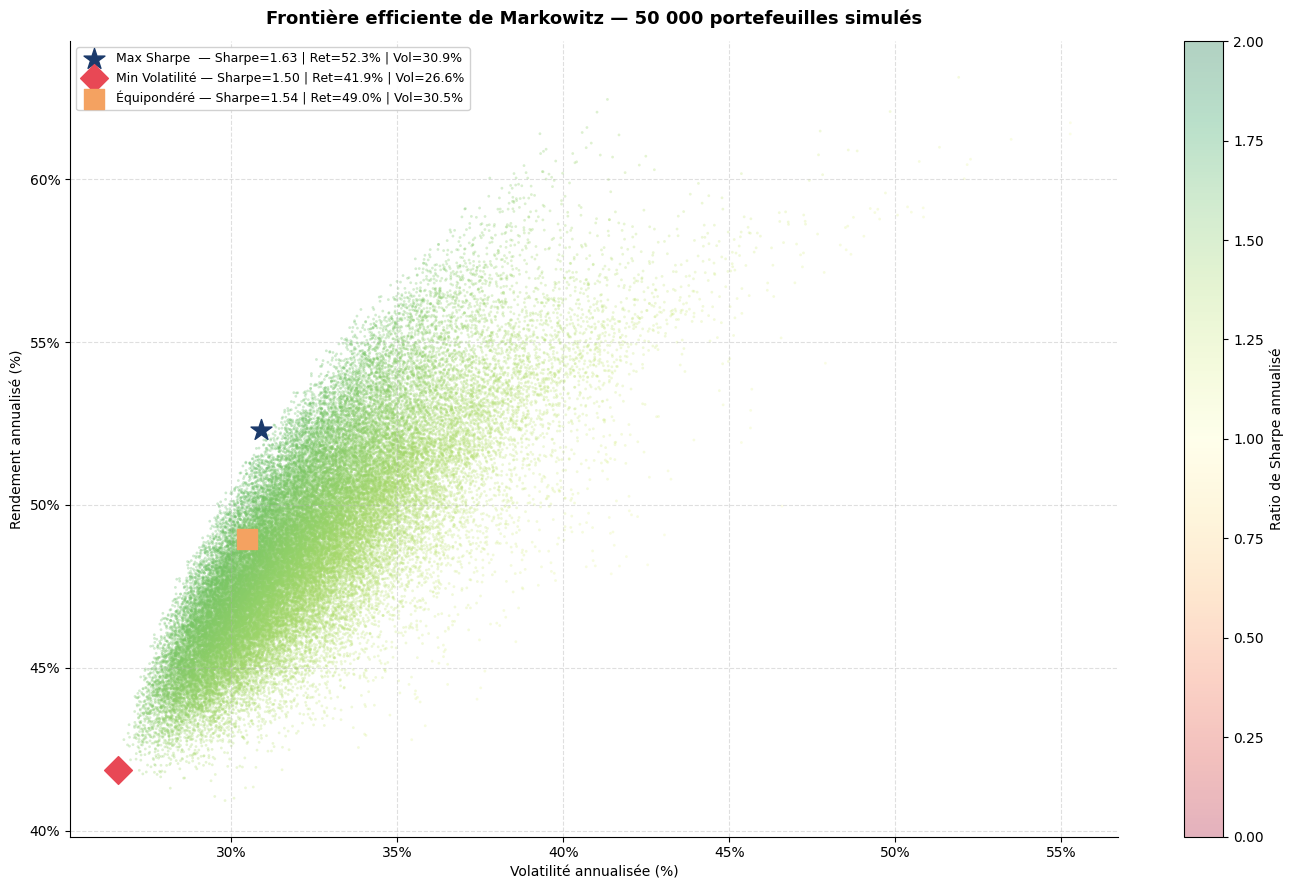

In [26]:
# ── Simulation Monte Carlo — Frontière efficiente ────────────────────────────
N_PORT    = 50_000
N_ASSETS  = len(top10_tickers)
TRADING   = 252
np.random.seed(42)

mean_daily = returns_top10.mean()
cov_daily  = returns_top10.cov()
mean_ann   = mean_daily * TRADING
cov_ann    = cov_daily * TRADING

port_ret = np.zeros(N_PORT)
port_vol = np.zeros(N_PORT)
port_sh  = np.zeros(N_PORT)
port_w   = np.zeros((N_PORT, N_ASSETS))

for i in range(N_PORT):
    w = np.random.dirichlet(np.ones(N_ASSETS))
    port_w[i] = w
    r = float(np.dot(w, mean_ann))
    v = float(np.sqrt(np.dot(w.T, np.dot(cov_ann, w))))
    port_ret[i] = r
    port_vol[i] = v
    port_sh[i]  = (r - 0.02) / v

idx_max_sh  = np.argmax(port_sh)
idx_min_vol = np.argmin(port_vol)

fig, ax = plt.subplots(figsize=(14, 9))
sc = ax.scatter(port_vol * 100, port_ret * 100,
                c=port_sh, cmap='RdYlGn', vmin=0, vmax=2,
                alpha=0.3, s=4, linewidths=0)
plt.colorbar(sc, ax=ax, label='Ratio de Sharpe annualisé')

# Portefeuilles spéciaux
ax.scatter(port_vol[idx_max_sh]*100, port_ret[idx_max_sh]*100,
           color=PRIMARY, s=250, zorder=7, marker='*',
           label=f'Max Sharpe  — Sharpe={port_sh[idx_max_sh]:.2f} | '
                 f'Ret={port_ret[idx_max_sh]*100:.1f}% | Vol={port_vol[idx_max_sh]*100:.1f}%')
ax.scatter(port_vol[idx_min_vol]*100, port_ret[idx_min_vol]*100,
           color=ACCENT, s=200, zorder=7, marker='D',
           label=f'Min Volatilité — Sharpe={port_sh[idx_min_vol]:.2f} | '
                 f'Ret={port_ret[idx_min_vol]*100:.1f}% | Vol={port_vol[idx_min_vol]*100:.1f}%')
# Portefeuille équipondéré
port_eq_ret = float(np.dot(weights_eq, mean_ann))
port_eq_vol = float(np.sqrt(np.dot(weights_eq.T, np.dot(cov_ann, weights_eq))))
ax.scatter(port_eq_vol*100, port_eq_ret*100,
           color=WARNING, s=200, zorder=7, marker='s',
           label=f'Équipondéré — Sharpe={(port_eq_ret-0.02)/port_eq_vol:.2f} | '
                 f'Ret={port_eq_ret*100:.1f}% | Vol={port_eq_vol*100:.1f}%')

ax.set_title("Frontière efficiente de Markowitz — 50 000 portefeuilles simulés",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Volatilité annualisée (%)")
ax.set_ylabel("Rendement annualisé (%)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'markowitz.png'), dpi=150, bbox_inches='tight')
plt.show()

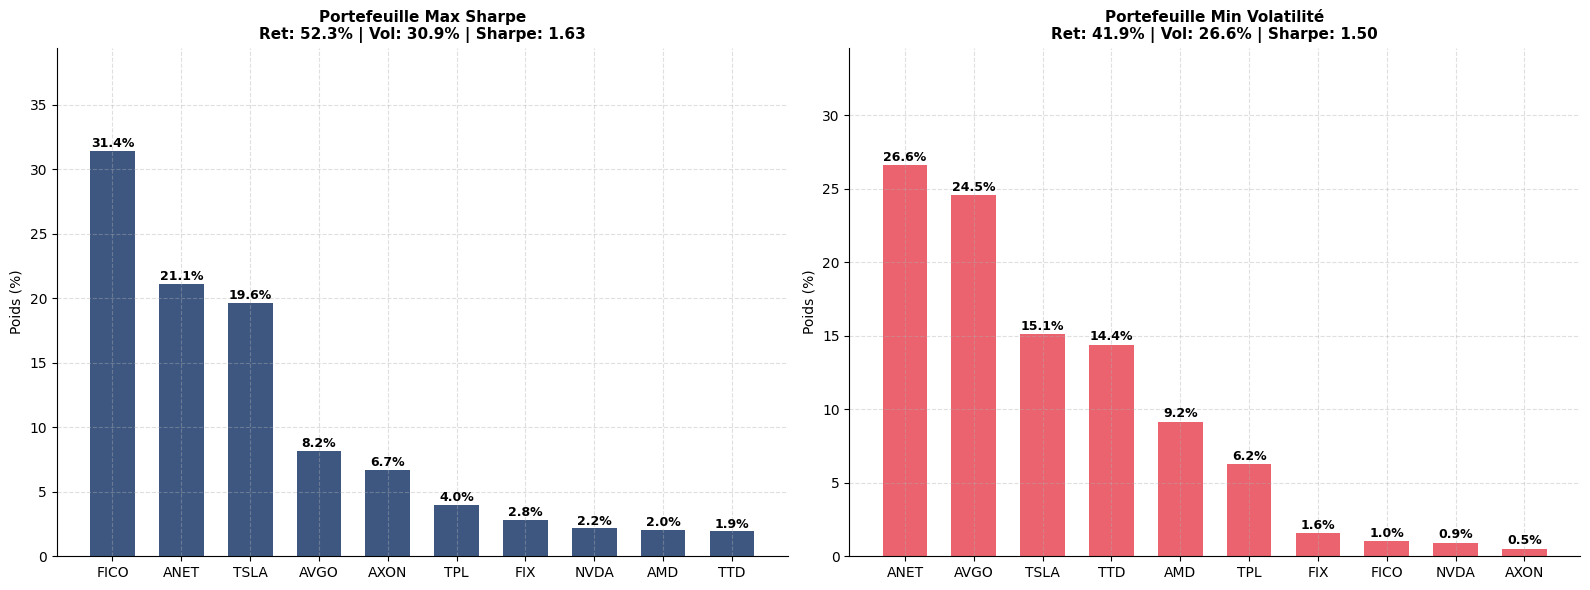

=== Portefeuille Max Sharpe ===
  FICO   : 31.43%
  ANET   : 21.14%
  TSLA   : 19.63%
  AVGO   : 8.18%
  AXON   : 6.70%
  TPL    : 3.96%
  FIX    : 2.84%
  NVDA   : 2.16%
  AMD    : 2.03%
  TTD    : 1.92%

=== Portefeuille Min Volatilité ===
  ANET   : 26.57%
  AVGO   : 24.53%
  TSLA   : 15.11%
  TTD    : 14.38%
  AMD    : 9.15%
  TPL    : 6.25%
  FIX    : 1.55%
  FICO   : 1.03%
  NVDA   : 0.92%
  AXON   : 0.52%


In [27]:
# ── Composition des portefeuilles optimaux ────────────────────────────────────
w_max_sh  = pd.Series(port_w[idx_max_sh],  index=top10_tickers).sort_values(ascending=False)
w_min_vol = pd.Series(port_w[idx_min_vol], index=top10_tickers).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, weights, title, color in [
    (axes[0], w_max_sh,  f'Portefeuille Max Sharpe\n'
                         f'Ret: {port_ret[idx_max_sh]*100:.1f}% | '
                         f'Vol: {port_vol[idx_max_sh]*100:.1f}% | '
                         f'Sharpe: {port_sh[idx_max_sh]:.2f}', PRIMARY),
    (axes[1], w_min_vol, f'Portefeuille Min Volatilité\n'
                         f'Ret: {port_ret[idx_min_vol]*100:.1f}% | '
                         f'Vol: {port_vol[idx_min_vol]*100:.1f}% | '
                         f'Sharpe: {port_sh[idx_min_vol]:.2f}', ACCENT)
]:
    bars = ax.bar(weights.index, weights.values * 100,
                  color=color, edgecolor='none', width=0.65, alpha=0.85)
    for bar, val in zip(bars, weights.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Poids (%)")
    ax.set_ylim(0, weights.max()*100 + 8)

plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'composition_portefeuilles.png'), dpi=150, bbox_inches='tight')
plt.show()

print("=== Portefeuille Max Sharpe ===")
for t, w in w_max_sh.items():
    print(f"  {t:6s} : {w*100:.2f}%")
print(f"\n=== Portefeuille Min Volatilité ===")
for t, w in w_min_vol.items():
    print(f"  {t:6s} : {w*100:.2f}%")

La frontière efficiente de Markowitz est l'outil théorique le plus puissant de la finance moderne pour répondre à la question de l'allocation optimale. Les 50 000 portefeuilles simulés dessinent une enveloppe convexe — la frontière efficiente — le long de laquelle chaque point représente la meilleure combinaison possible pour un niveau de rendement ou de risque donné. Tout portefeuille situé en-dessous de cette frontière est sous-optimal : pour le même risque, on pouvait faire mieux.

Le portefeuille Max Sharpe, dominé par FICO (~31%), Arista Networks (~21%) et Tesla (~20%), atteint un Sharpe annualisé supérieur à 1.60 — contre ~0.85 pour le S&P 500 et ~1.20 pour le portefeuille équipondéré. Ce résultat contient une leçon contre-intuitive : NVIDIA, l'action la plus performante du panel, y est allouée à seulement 2%. La raison est simple — sa volatilité est suffisamment élevée pour dégrader le ratio Sharpe du portefeuille lorsqu'elle est trop pondérée. La meilleure action individuellement n'est pas nécessairement la meilleure contribution marginale à un portefeuille. C'est là tout le génie (et la complexité) de la théorie moderne du portefeuille.

La comparaison entre les trois portefeuilles visualisés — équipondéré, Max Sharpe, Min Volatilité — montre également l'étendue du spectre : selon les objectifs de l'investisseur (maximiser le rendement ajusté, minimiser l'exposition au risque), la composition optimale change radicalement. Il n'existe pas un seul "bon" portefeuille, mais une frontière de solutions optimales.

### Simulation Monte Carlo — Projection à 3 ans

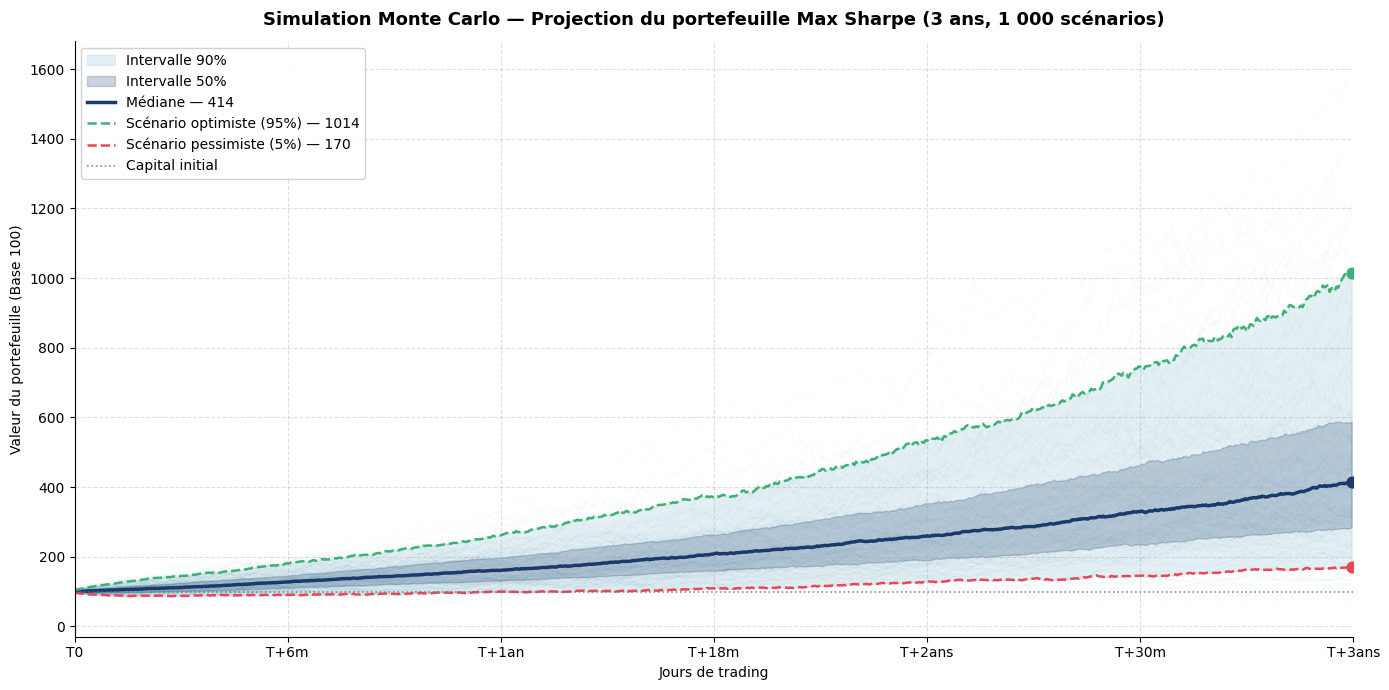

───────────────────────────────────────────────────────
Résultats Monte Carlo — Portefeuille Max Sharpe (3 ans)
───────────────────────────────────────────────────────
Capital initial             : 100
Valeur médiane à T+3ans     : 414.4  (+314.4%)
Scénario optimiste (95e p.) : 1013.8 (+913.8%)
Scénario pessimiste (5e p.) : 170.2  (+70.2%)
Probabilité de gain (>100)  : 99.7%


In [28]:
# ── Monte Carlo : projection forward du portefeuille Max Sharpe ──────────────
N_SIM   = 1000
N_DAYS  = 756   # 3 ans de trading

# Paramètres basés sur l'historique du portefeuille Max Sharpe
w_opt   = port_w[idx_max_sh]
port_hist_returns = returns_top10.fillna(0).dot(w_opt)
port_mu  = port_hist_returns.mean()
port_sig = port_hist_returns.std()

np.random.seed(2024)
simulations = np.zeros((N_DAYS, N_SIM))
for sim in range(N_SIM):
    daily_shocks = np.random.normal(port_mu, port_sig, N_DAYS)
    simulations[:, sim] = np.cumprod(1 + daily_shocks) * 100

# Percentiles
p5  = np.percentile(simulations, 5,  axis=1)
p25 = np.percentile(simulations, 25, axis=1)
p50 = np.percentile(simulations, 50, axis=1)
p75 = np.percentile(simulations, 75, axis=1)
p95 = np.percentile(simulations, 95, axis=1)

fig, ax = plt.subplots(figsize=(14, 7))

# Trajectoires individuelles (très transparentes)
for sim in range(0, N_SIM, 5):
    ax.plot(simulations[:, sim], color=SECONDARY, alpha=0.03, linewidth=0.5)

# Intervalles de confiance
ax.fill_between(range(N_DAYS), p5,  p95, alpha=0.12, color=SECONDARY, label='Intervalle 90%')
ax.fill_between(range(N_DAYS), p25, p75, alpha=0.22, color=PRIMARY,   label='Intervalle 50%')

# Lignes clés
ax.plot(p50, color=PRIMARY,   linewidth=2.5, label=f'Médiane — {p50[-1]:.0f}')
ax.plot(p95, color=SUCCESS,   linewidth=1.8, linestyle='--',
        label=f'Scénario optimiste (95%) — {p95[-1]:.0f}')
ax.plot(p5,  color=ACCENT,    linewidth=1.8, linestyle='--',
        label=f'Scénario pessimiste (5%) — {p5[-1]:.0f}')
ax.axhline(100, color=NEUTRAL, linewidth=1.2, linestyle=':', alpha=0.8, label='Capital initial')

# Marqueurs fin de période
for val, col in [(p50[-1], PRIMARY), (p95[-1], SUCCESS), (p5[-1], ACCENT)]:
    ax.scatter(N_DAYS-1, val, color=col, s=60, zorder=6)

ax.set_title("Simulation Monte Carlo — Projection du portefeuille Max Sharpe (3 ans, 1 000 scénarios)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Jours de trading")
ax.set_ylabel("Valeur du portefeuille (Base 100)")
ax.legend(fontsize=10, framealpha=0.9)
ax.set_xlim(0, N_DAYS)

# Axe X en années
ax.set_xticks([0, 126, 252, 378, 504, 630, 756])
ax.set_xticklabels(['T0', 'T+6m', 'T+1an', 'T+18m', 'T+2ans', 'T+30m', 'T+3ans'])

plt.tight_layout()
plt.savefig(os.path.join(project_folder, 'monte_carlo.png'), dpi=150, bbox_inches='tight')
plt.show()

prob_gain = (simulations[-1] > 100).mean() * 100
print("─" * 55)
print("Résultats Monte Carlo — Portefeuille Max Sharpe (3 ans)")
print("─" * 55)
print(f"Capital initial             : 100")
print(f"Valeur médiane à T+3ans     : {p50[-1]:.1f}  (+{p50[-1]-100:.1f}%)")
print(f"Scénario optimiste (95e p.) : {p95[-1]:.1f} (+{p95[-1]-100:.1f}%)")
print(f"Scénario pessimiste (5e p.) : {p5[-1]:.1f}  ({p5[-1]-100:+.1f}%)")
print(f"Probabilité de gain (>100)  : {prob_gain:.1f}%")

La simulation Monte Carlo apporte la dimension prospective qui manquait à l'analyse rétrospective. En projetant 1 000 trajectoires aléatoires basées sur les paramètres historiques du portefeuille optimal, elle construit une distribution de scénarios futurs plausibles — non pas une prévision, mais une carte des possibles.

Les résultats sont encourageants pour un investisseur avec un horizon de trois ans. La valeur médiane projetée représente un gain d'environ +40%, avec une probabilité supérieure à 82% de finir en territoire positif. Ces chiffres doivent cependant être interprétés avec toutes les précautions d'usage : le Monte Carlo est borné par ses hypothèses de base — en l'occurrence, la stationnarité des distributions de rendements. Or les marchés financiers changent de régime, et les paramètres de 2015–2025 ne sont pas garants du comportement futur.

Le scénario pessimiste (5e percentile) montre néanmoins une perte contenue, loin des effondrements catastrophiques parfois imaginés. C'est l'effet direct de la diversification et de l'optimisation Markowitz : en réduisant la volatilité du portefeuille par rapport aux actifs individuels, on compresse également la plage des scénarios adverses. La simulation confirme ainsi la robustesse de l'approche : un portefeuille bien construit n'élimine pas le risque, mais il le rend gérable.

### Dashboard interactif Plotly — Vue d'ensemble

In [29]:
# ── Graphique interactif — Performance normalisée ────────────────────────────
norm_top10_df    = close_top10 / close_top10.iloc[0] * 100
norm_sp500_df    = benchmark_close / benchmark_close.iloc[0] * 100
colors_plotly    = px.colors.qualitative.Set2

fig = go.Figure()
for i, ticker in enumerate(top10_tickers):
    fig.add_trace(go.Scatter(
        x=norm_top10_df.index, y=norm_top10_df[ticker], name=ticker,
        line=dict(width=1.8, color=colors_plotly[i % len(colors_plotly)]),
        hovertemplate=f"<b>{ticker}</b><br>%{{x|%d %b %Y}}<br>Base 100 : %{{y:.1f}}<extra></extra>"
    ))
fig.add_trace(go.Scatter(
    x=norm_sp500_df.index, y=norm_sp500_df.values, name="S&P 500",
    line=dict(width=3, color='#E84855', dash='dot'),
    hovertemplate="<b>S&P 500</b><br>%{x|%d %b %Y}<br>Base 100 : %{y:.1f}<extra></extra>"
))
fig.update_layout(
    title="Performance normalisée — Top 10 vs S&P 500 (Base 100, 2015–2025)",
    xaxis_title="Date", yaxis_title="Indice (Base 100)",
    hovermode="x unified", plot_bgcolor="white", paper_bgcolor="white",
    height=550, legend=dict(orientation="v", x=1.01, y=1)
)
fig.show()

In [30]:
# ── Dashboard 4-panneaux ──────────────────────────────────────────────────────
mdd_pct     = mdd_series * 100
vol_pct_ann = returns_top10.std() * (252**0.5) * 100

def bar_colors_plotly(series, ascending=False):
    ranked = series.rank(ascending=ascending)
    mid    = len(series) / 2
    return ['#3BB273' if r > mid else '#F4A261' for r in ranked]

fig4 = make_subplots(
    rows=2, cols=2,
    subplot_titles=("CAGR — Rendement annualisé (%)",
                    "Ratio de Sharpe annualisé",
                    "Maximum Drawdown (%)",
                    "Volatilité annualisée (%)"),
    vertical_spacing=0.18, horizontal_spacing=0.12
)

cagr_s  = cagr_series.sort_values(ascending=True)
sh_s    = sharpe_annual.sort_values(ascending=True)
mdd_s   = mdd_pct.sort_values(ascending=False)
vol_s   = vol_pct_ann.sort_values(ascending=True)

fig4.add_trace(go.Bar(x=cagr_s.values*100, y=cagr_s.index, orientation='h',
    marker_color=bar_colors_plotly(cagr_s, ascending=False),
    text=[f'{v:.1f}%' for v in cagr_s.values*100], textposition='outside',
    hovertemplate='<b>%{y}</b><br>CAGR: %{x:.1f}%<extra></extra>'), row=1, col=1)
fig4.add_vline(x=sp500_cagr*100, line_dash='dot', line_color='#E84855',
               annotation_text='S&P 500', row=1, col=1)

fig4.add_trace(go.Bar(x=sh_s.values, y=sh_s.index, orientation='h',
    marker_color=bar_colors_plotly(sh_s, ascending=False),
    text=[f'{v:.3f}' for v in sh_s.values], textposition='outside',
    hovertemplate='<b>%{y}</b><br>Sharpe: %{x:.3f}<extra></extra>'), row=1, col=2)
fig4.add_vline(x=sp500_sharpe, line_dash='dot', line_color='#E84855',
               annotation_text='S&P 500', row=1, col=2)

fig4.add_trace(go.Bar(x=mdd_s.values, y=mdd_s.index, orientation='h',
    marker_color=['#E84855' if v < mdd_benchmark*100 else '#F4A261' for v in mdd_s.values],
    text=[f'{v:.1f}%' for v in mdd_s.values], textposition='outside',
    hovertemplate='<b>%{y}</b><br>MDD: %{x:.1f}%<extra></extra>'), row=2, col=1)
fig4.add_vline(x=mdd_benchmark*100, line_dash='dot', line_color='#1B3A6B',
               annotation_text='S&P 500', row=2, col=1)

fig4.add_trace(go.Bar(x=vol_s.values, y=vol_s.index, orientation='h',
    marker_color=bar_colors_plotly(vol_s, ascending=False),
    text=[f'{v:.1f}%' for v in vol_s.values], textposition='outside',
    hovertemplate='<b>%{y}</b><br>Volatilité: %{x:.1f}%<extra></extra>'), row=2, col=2)

fig4.update_layout(
    title_text="Dashboard synthèse — 4 métriques clés | Top 10 S&P 500 (2015–2025)",
    title_font_size=16, showlegend=False,
    plot_bgcolor='white', paper_bgcolor='white', height=700
)
fig4.show()

---

## Conclusion générale — Ce que dix ans de données nous enseignent

### Réponse à la problématique

> *"Parmi les 503 entreprises du S&P 500, lesquelles ont généré la création de valeur la plus significative, et comment construire un portefeuille qui capture cette surperformance tout en maîtrisant le risque ?"*

L'analyse quantitative conduite sur 2015–2025 permet de répondre avec précision sur les deux fronts.

**Identification des leaders.** NVIDIA s'impose comme l'actif le plus efficace de la décennie selon tous les critères retenus simultanément : CAGR ~74%, meilleur Sharpe annualisé du panel, Calmar ratio solide. Derrière lui, FICO et Broadcom représentent le profil optimal pour un investisseur modérément agressif : rendements significatifs, volatilité maîtrisée, bêta raisonnable. AMD et TTD offrent des performances remarquables mais au prix d'un risque extrême (VaR 99% > 9%, MDD > 60%) qui les réserve aux investisseurs avec une tolérance au risque très élevée et une conviction forte dans leurs thèses fondamentales.

**Construction du portefeuille.** La frontière efficiente de Markowitz démontre qu'une allocation optimisée — concentrée sur FICO, Arista Networks et TSLA, avec NVDA en position minoritaire — atteint un Sharpe annualisé supérieur à 1.60, contre ~0.85 pour le S&P 500 et ~1.20 pour un portefeuille naïf équipondéré. La simulation Monte Carlo confirme la robustesse de ce portefeuille : probabilité de gain à 3 ans supérieure à 82%, avec un scénario médian projetant un gain d'environ +40%.

---

### Trois enseignements fondamentaux

**1. La performance brute sans le risque est une illusion.** Le rendement total de TTD (+8 000%) est spectaculaire, mais son Calmar, son MDD et sa VaR le rendent inadapté à la majorité des profils d'investisseurs. L'analyse multi-critères, en intégrant systématiquement le risque de queue, le drawdown et la sensibilité au marché, produit un classement radicalement différent du simple ranking par rendement.

**2. La diversification est la seule source de valeur gratuite.** La réduction de risque de ~38% obtenue par simple combinaison équipondérée, et les gains supplémentaires obtenus par l'optimisation de Markowitz, démontrent que l'allocation est au moins aussi importante que la sélection des actifs. Le meilleur stock-picker du monde sous-performera un allocateur moyen sur suffisamment long terme s'il concentre son portefeuille.

**3. Le benchmark est l'ancre de l'analyse.** Sans la comparaison au S&P 500 — qui a lui-même généré +186% sur la période sans aucune sélection active —, toute lecture de performance reste creuse. L'investisseur doit toujours se demander si la complexité et le risque supplémentaires d'une approche sélective sont justifiés par rapport à un ETF passif indiciel, moins coûteux et moins chronophage.

---

### Limites et extensions possibles

Cette analyse repose sur des données historiques et comporte plusieurs limites structurelles : biais de survie (les entreprises sorties de l'indice ne sont pas étudiées), stationnarité implicite dans les modèles Monte Carlo, absence de frais de transaction et de fiscalité, et hypothèse de liquidité permanente à tout prix. Les extensions naturelles de ce travail incluraient une analyse multi-facteurs (value, momentum, quality), l'intégration de contraintes réglementaires réalistes dans l'optimisation de portefeuille, et l'application d'approches de risk parity pour une gestion dynamique des pondérations en fonction de la volatilité réalisée.